The next note cell is course transcript.

Hi everybody and welcome to “Deep Learning Foundations to Stable Diffusion”. Hopefully  it's not too confusing that this is described here as Lesson 9, that's because strictly  speaking we treat this as Part 2 of the “Practical Deep Learning for Coders” series.  So that Part 1 had eight lessons so this is lesson nine. But don't worry you didn't miss anything,  it's the first lesson of Part 2, which is called “Deep Learning Foundations to Stable Diffusion”  and maybe rather than calling it “Practical Deep Learning for Coders” we should call this  “Impractical Deep Learning for Coders” in the sense that we are certainly not going to be  spending all of our time seeing exactly how to do important things with with deep learning.  But we'll be doing a whole lot of fun things —generative modely fun things— and also a  whole lot of understanding lots of details which you won't necessarily need to know  to use this stuff but, if you want to become a researcher or if you want to, like, put something  in production —which has got like some kind of complex customization requirements, stuff  like that, then it is going to be very helpful to learn the details we'll be talking about. So here in Lesson 9, there's kind of going to be two parts to it. One  is just a quick run through —quickish run through of using Stable Diffusion—  Because we're all dying to play with it, right? And then  the other thing that I'll be doing is describing in some detail what's going on, how is it working. There'll be a whole lot of hand waving, either way, because it's going to take  us a few lessons to describe everything from scratch but hopefully, you know,  you'll get a, you'll feel like you'll come away from this, with this lesson with a reasonable,  you know, intuitive understanding, at least, of how how this is all working. Assumptions. Well, I'm going to try to explain everything,  like, everything. I'm going to try to explain everything so, like, if you haven't  done Deep Learning before this is going to be very hard but I will at least be trying to say like,  this is roughly what's going on and where you can find out more. Having said that, I would strongly suggest doing Part 1 before doing this course unless  you really want to throw yourself in the deep, deep end and give yourself quite, quite a test.  If you haven't done Part 1 of “Practical Deep Learning for Coders”. But you're, you know,  reasonably comfortable with Deep Learning basics, you could like, write a basic SGD loop in Python.  And you know, you know, how to use, ideally Pytorch —but Tensorflow is probably okay as well.  And you kind of know the basic ideas of how to create, you know, what an embedding is and you  could create one of those from scratch, stuff like that, you know, you'll probably be fine. Generally speaking, for these courses, I find most people tend to watch the  videos a few times and often the second time through folks will like pause and  look things up they don't know and check things out. Generally speaking, you know,  we expect people to be spending about 10 hours of work on each video. Having said that some  people spend a hell of a lot more and go very deep, some people will spend a whole year,  you know, sabbatical studying “Practical Deep Learning for Coders” in order to really  fully understand everything so really it's up to you as to how deep you go. Okay, so, with that said, let's jump into it. As I said the first part we're going  to be playing around with Stable Diffusion and I, you know, try to,  you know, prepare this as late as possible so it wouldn't be out of date.  Unfortunately, as of 12 hours ago, it is now out of date, and this is one of the big issues  with the bit I'm about to describe which is like: how to play with Stable Diffusion,  exactly how do the details work. Which is, it's moving so quickly that all of the details I'm  going to describe to you today and all of the software I'm going to show you today,  by the time you watch this, if you're watching it —so what is it we're up to now, it's 11th of  October— so if you're watching this in, like, December of 2022, or watching this in 2023,  the details will have changed. So what's happened today in the last 24 hours is: two  papers have come out so what I was going to be telling you today is for example to do a  Stable Diffusion generative model the number of steps required has gone down from a thousand to  about 40 or 50, but then as of, yeah, last night, papers just come out that's saying  it's now down to 4, that is, 256 times faster. And another paper has come out with a separate  —I think— orthogonal approach, which makes it another, let's see, 10 to 20 times faster. So things are very exciting. Things are moving very quickly. Now, having said that, don't worry  because after this lesson we're going to be going from the foundations —which means we're going to  be learning all the things of how these are built up— and those don't change much at all. And in  fact a lot of what we'll be seeing is extremely similar to another course we did in 2019,  because the foundations don't change and once you know the foundations these kinds of details  about the stuff that you'll find in these papers, you'll be like: “oh, I see, they did all these  things the same way as usual and they made this little change”. So that's why we do things from  the foundations, so that you can keep up with the research, do your own research by taking  advantage of this foundational knowledge which, you know, all these papers are building on top of. So anyway, I guess I should apologize that even as I record this,  you know, the notebook is now one day out of date. So in Part 1, you know, you might remember we saw this stuff of Dall-e 2 illustrations of Twitter,  by Twitter bios, which really are pretty cool.  So, you know, the cool thing is that we're now at a point we can build this stuff ourselves,  and run this stuff ourselves. We won't actually be using this particular model Dall-e 2, we’ll be  using a different model: Stable Diffusion. But has very similar kind of outputs. But we can go even  further now, so, one of our wonderful alumni, Alon, actually recently started a new company  called —I don't know who said— it's strumer (strmr.com) where you can use something that  we'll be learning about today, called Dreambooth, to put any object, person, whatever into an image.  And so he was kind enough to do a quick Dreambooth run for me and added these various pictures of me  using his service. So here's a fun service you can try. One crazy one he tried was me as a dwarf  which, I gotta say, actually worked pretty well. This half looks like me, I reckon,  and then the bottom bit is the dwarf version. So thank you a lot and congratulations on  your great progress since completing the fastai course. Yeah, I love it. So, something that's a bit different about this compared to previous courses —a lot  of previous courses— is this is no longer just a me thing because this is moving so  quickly I've needed to get a lot of help to even vaguely get up at the gate and stay up to date.  So everything I'll be showing you today is very heavily influenced by extremely  high levels of input from these amazing folks —all of whom are fast AI alumni.  So Jonathan Whitaker —who I saw in our chat— is, was basically the first guy to create detailed  educational material about Stable Diffusion and has been in the generative model space,  well, for a long time by Stable Diffusiony standards —I guess.  So Wasim um has been an extraordinary contributor to all-things fastai.  Petro came to San Francisco for the last time we did a Part 2 course in 2019 and  took what he learned there and made his amazing Camera+ software dramatically better and had it  highlighted by Apple for the extraordinary Machine Learning stuff added and he's now at Hugging Face  working on the software that we'll be using a lot —diffusers— and then Tanishq —everybody in  the forum of the fastai community probably already knows— now at Stability.Ai working  on Stable Diffusion models, his expertise particularly as in medical applications. So really folks from all the key groups —pretty much— around Stable Diffusion and  stuff are working on this together. And you'll also find some of these folks have recorded  additional videos going into more detail about some of the areas which you'll find on the,  on the course website. So make sure you go to course.fast.ai to get all the information  about, you know, all the materials that you need to take full advantage of this. So every lesson  has links to notebooks and to details and so forth. If you want to go even deeper,  head over to forums.fast.ai, enter the Part 2 2022 category,  hit on the “about the course” button and you'll find that every lesson there's a chat  with even more stuff. So look at this carefully to see all the things that me and the community  have provided to you to help you understand this video and also check out the questions underneath  and answers underneath to see what people have talked about. They can get a bit overwhelming so  once they get big enough they'll, you'll see that there's a summarize button that you can,  that you can click to kind of see just the most liked parts. So that can be very helpful. Okay so, they're all important resources, I think,  to get the most, to get the most out of this course. Now, compute, so I'm completing Part 2 requires quite a bit more compute than Part 1.  Compute options are changing rapidly and, to be honest, the main reason for that is because of  the huge popularity of Stable Diffusion. Everybody is taken to using Colab for Stable Diffusion and  Colab's response has been to start charging by the hour for most usage. So you may well find if  you're a Colab user —we still love Colab. You may find that, you know, you run out of, they start  not giving you decent GPUs anymore and if you want to then upgrade, they limit quite a lot how many  hours you can use. So at the moment, yeah, still try Colab, they're pretty good, I mean, for free  you get some decent stuff, but I would strongly suggest trying out also Paperspace Gradient. You  can pay like nine dollars a month to actually get some pretty good GPUs there at the moment.  Or I'll pay them a bit more to get even better ones. Again, but the thing is this is all going  to change a lot, I don't know, like, maybe people will make Paperspace Gradient have to change their  pricing too, I don't know, so check course.fast.ai to find out what our current recommendations are. Now, Lambda Labs and Jarvis Labs are also both good options. Jarvis was created by alum of the  course and has some just really fantastic options at a very reasonable price. And a  lot of fastai students use them and love them. And also check out Lambda Labs who are the most recent  provider on this page and they are rapidly adding new features. But the reason I particularly  wanted to mention them is, at least as I say this, which as I say is early October 2022,  they're the cheapest provider of kind of big GPUs that you might want to use to run like  serious models. So they're absolutely, yeah, well worth checking out. But as I say,  this could all have changed by the time you watch this, so go and check out course.fast.ai. Also, at the moment: late 2022, GPU prices have come down a lot and you may well want  to consider buying your own machine at this point. Okay so what we're now going to do is jump into the notebooks  and so there's a repo that we've linked to called “diffusion-nbs”  which isn't kind of the main course notebooks —it's not the “From the Foundations Notebooks…”—  there's just a couple of notebooks that you might want to play with, a bit of fun stuff to  try out. One of the interesting things here is… Jonathan Whitaker —who I tend to call Johno so,  if I say Johno, that's who I'm referring to— has created this really interesting thing  called suggested_tools.md which hopefully he'll keep up to date so, even if you come here later,  this will still be up to date. Because he knows so much about this area he's been able to pull out  some of the best stuff out there for just starting to play. And I think it's actually important to  play because that way you can really understand what the capabilities are and what the constraints  are so that then you can think about like, well, what could you do with that and also, like, what  kind of research opportunities might there be. So I'd strongly suggest trying out these things. The community on the whole has moved towards  making things available as Colab notebooks, so if I click, for example, on this one: Deforum.  And they often have this kind of hacker aesthetic around them, which is kind of fun.  So what happens is like just they add lots and lots of features and you can  basically just fill in this stuff to try… to try things. And they often have a few examples  and so you can hit up the Runtime and say: Change Runtime Type to make sure it says GPU,  and you can say what kind of GPU, and start running things. Now,  a lot of the folks who use this stuff honestly have no idea what any of these things mean,  now, by the end of the course you all know what all of these things mean, pretty much. And that  will help you to make great outputs from stuff like this. But you can create out great outputs  just using more of an artisanal approach, there's lots of information online about,  you know, what kinds of things could you try. So, anyway, check out this stuff from from Johno.  And then he also links to this fantastic resource from pharmapsychotic which  is rather overwhelming list of things to play with. Now again, you know, maybe by the time you  watch this this is all changed but I just wanted to know these kind of things are out there and  they're basically like ready to go applications that you can start playing with. So play a lot. What you'll find is that most of them —at least at the moment— expect you to input some text to say  what you want to create a picture of. It turns out that, as we'll learn, we'll learn in detail why,  the text you pick it's not very easy to know what to write and and that gives kind of interesting  results. At the moment it's quite an artisanal thing to understand what to write and the best  way to learn what to write —is called the The Prompt— the best way to learn about prompts is to  look at other people's prompts and their outputs. So at the moment perhaps the best way to do that  is Lexica which has lots and lots of really interesting artworks.  And so, AI artworks, and so you can click on one and see what prompt was used.  And so you'll see here that, generally, you start with what do you want to take… make a picture of,  what's the style and then the trick is to add a bunch of, like,  artists names or places that they put art so that the algorithm will tend to create a  piece which matches art, you know, that tends to have the these kinds of words in their captions.  So there's a really useful trick to, kind of, get good at this. And so you can even  search for things —so I don't know if they have teddy bears, let's try—  there we go, so if there's a kind of like a —probably not that one— that's a pretty good  teddy bear image. So you can kind of get some sense of how to create nice teddy bear images.  So cute —I know what I'm going to be showing my daughter tomorrow. You can see they often  tend to have similar kinds of stuff to try to encourage the algorithm to give good outputs. Okay so by the end of this course you'll understand  why this is happening: why these kinds of out, you know, prompts create these  kind of outputs and also how you can go beyond just creating prompts to actually,  to actually, building really innovative new things with new data types. Okay. So let's take a look at the diffusion-nbs repo, the first thing  we'll look at is stable_diffusion(.ipybn) So a couple of options here. You can,  you can clone this repo which is linked from both the course.fast.ai and from the forum  and run it on like Paperspace Gradient or your own machine or whatever. Or you can head over to Colab  and you can just say GitHub, right, and then you can paste in the link to it directly from GitHub. Okay, so, I'm running it on my own machine  and this notebook is largely been built thanks to the wonderful folks at Hugging Face and Hugging  Face have a library called Diffusers, so any of you that have done Part 1 of the course  will be very familiar with Hugging Face. We used a lot of their libraries in Part 1.  Diffusers is their library for doing Stable Diffusion. And stuff like Stable Diffusion.  At the moment, you know, these things are changing a lot but, at the moment,  this is our recommended library for doing this stuff and it's what we'll be using in this course.  Maybe by the time you watch this there'll be lots of other options, so again, keep an  eye on course.fast.ai. In general Hugging Face have done a really good job of being  at and staying at the kind of head of the pack around models in general for Deep Learning so,  that would be, you know, not surprising if they continue to be the best option for quite a while.  But the basic idea of any library is going to look pretty similar. So, to get started playing with this you will need to log in to Hugging Face.  So if you've got a Hugging Face you can create a username there and a password and then login.  Once you've done it once it'll save it on your computer so you won't have to log in again.  And the thing we're going to be working with is pipelines and in particular the Stable Diffusion  Pipeline. Again, you know, that you might be using different pipelines by the time that  you watch this. But the basic idea of pipeline is quite similar to what we call a Learner in fastai,  which is it's got a whole bunch of things in it, you know, a bunch of,  kind of, processing and models and inference, all happening automatically. And just like you  can save a pipeline in fastai, sorry, save a Learner in fastai, you can save a pipeline  in Diffusers. Now something that you can do in all pretty much all Hugging Face libraries,  you can't do in fastai, is you can then save a pipeline —or whatever— back up into the cloud  onto Hugging Face —they call it the Hub— and so then if we say from_pretrained(),  it's a lot like how we create pre-trained Learners in firstai but the thing you put here is actually  —if it's not a local path— it's a Hugging Face repo. So if we search Hugging Face for this,  and you can see  this is what it's going to download. And you can actually save your own pipelines up to the hub  for other people to use. So I think this is a very nice feature that helps, you know, the community  build stuff. So this is actually going to… the first time you run this, it's going to download  many gigabytes of data from the internet. This is one of the slight challenges with using this on  Colab is every time you use Colab everything gets thrown away and start from scratch so,  it'll all have to be downloaded every time you use Colab. If you use something like  Paperspace or particularly actually Lambda Labs it's all going to be saved for you. So once you've downloaded all this it's going to be, it's going to save a whole bunch of stuff  into your dot cache in your home directory, so that's where Hugging Face puts things. So now  that we have a pipeline called pipe we can now treat it as if it's a function —which is pretty  common for like Pytorchy stuff and fastai stuff, you should be very familiar with this hopefully. And you can pass it a prompt. And so this is just some text. And that's going to  return some images. Since we're only passing one prompt it's going to return one image,  so we'll just index into dot images. And when we run it, it takes uh, you know,  maybe 30 seconds or so and returns “a photograph of an astronaut riding a horse”.  Every time you call a pipeline using the same random seed you'll get the same image.  You can send them at the random seed manually, and so you could send to somebody else and say: “oh!,  this is a really cool astronaut riding a horse, I found, try manual seed 1024. And you'll get  back this particular astronaut riding a horse. So that's how you can, like, that's the most  basic way to get started running on Colcab or on your own machine, you can start creating images. It takes, as I said, takes 30 seconds or so and in this case it took 51 steps. What it's doing, this  is a bit very different to like what we're used to with inference in fastai, where it's one step to  classify something, for example. What it's doing in these 51 steps is: it's starting with like,  so this is actually an example that we're going to create ourselves, ourselves in the course of  creating handwritten digits, and this is actually an image from a later notebook we'll be building.  Well it basically starts with random noise and each step it tries to make it slightly less noisy  and slightly more like the thing we want. And so going down here is showing all the steps to  create the first four, for example, or here to create the first one. And if you look closely,  you can kind of see, in this noise, there is something that looks a bit like a one and so it  kind of decides to focus on that. And so that's how these diffusion models, basically, work.  So remember, if you're having any trouble finding the materials we're looking at to,  go to course.fast.ai or go to the forum topic to see all the links. And this one is called  diffusion dash nbs, and the notebook is called —you can see it at the top— stable_diffusion. Now, a question might be, well why don't we just do it in one go, and we can do it  in one go but if we try to do it in one go it doesn't do a very good job. These models aren't,  as I speak now in October 2022, smart enough to do it in one go. Now as I mentioned,  at the start, the fact that I'm doing it in 51 steps here is, you know, hopelessly out of date  because as of yesterday, apparently, we can now do it in three to four steps —I'm not sure if  that code's available yet— so by the time you see this, yeah, this might all be dramatically faster,  but as I'll be describing, understanding this basic concept —I'm pretty confident  it's going to be very important, like, forever— so we'll talk about that. So if we do 16 steps  instead of 51 steps, you know, it looks a bit more like it but it's still not amazing. Okay, so, that's how you can kind of get started and I'll show you a few things that you can tune  and, you know, I should remind you that, you know, we're not… most of the stuff I'm showing  you in this was built by Pedro Cuenca and the other folks at Hugging Face so,  huge thanks to them, there's no way I could have been as up to up to speed with all this  detail without their help. They built this library Diffusers and have done a fantastic job of helping  display what you can do with it. So let's look at an example of what you can do with it, we're just  going to quickly define a little function here to create a grid of images —the details don't matter.  But what we do want to show here is: you can take your prompt, which is “an astronaut  riding a horse” and just create four copies of it. Okay so, times, when applied to a list,  simply copies the list that many times, so here's a list of the exact same prompt, four times.  And then what we're going to do is we're going to pass to the pipeline the prompts and we're  going to use a different parameter now, called “guidance scale”. We're going to be learning  about “guidance scale”, in detail, later in the course but basically, what this does is,  it says to what degree should we be, kind of, focusing on the specifics caption versus just  creating an image. So we're going to try a few different guidance scales, about 1, 3,  7, 14. Generally seven and a half, I believe, at this stage is the default, that may have changed  by the time you watch this. And so each row here is a different “guidance scale”.  So you can see, in the first row, it hasn't really listened to us very much at all, these  are very weird looking things in there, none of them really look like “astronauts riding a horse”.  At guided scale of 3, they look more like things riding horses, that they might be  astronautish and at 7.5 they're certainly, on the whole, look like astronauts riding a horse  and at 14 or 15 they certainly look like that but they're getting a little bit too abstract  sometimes. I have a pretty strong feeling there are some slight problems with actually how this  is coded, or actually how the algorithm works which I will be looking at during this course  so maybe, by the time you see this, some of these will be looking a bit better.  I think basically something that's happening here is it's actually, kind of, over…  over jumping a bit too far during these high ones. Anyway, so, the basic idea of what it's doing here is, this guidance is, it's basically actually,  for every single prompt, it's creating, creating two versions: one version of the image with the  prompt —“an astronaut riding a horse”— and one version of the image with no prompt. So  it's just some random thing, and then it takes the average, basically, of those two things.  And that's how, that's what “guidance scale” does, and you can kind of think  of the “guidance scale” as being a bit like a number that's used to weight the average. There's something very similar you can do, where again, you create, get the model to create two  images but, rather than taking the average, you can ask it to effectively subtract one from the  other. So, here's something that Pedro did of using the prompt a “Labrador in the style  of Vermeer”. And then he said, well, what if we then subtract something which is just the model  for the caption blue. And you can pass in this thing “negative prompt” to diffusers and what  that will do is it will take the prompt, which in this case is “Labrador in the style of Vermeer”,  and create a second image, effectively, which is just responding to the prompt “blue” and  effectively subtract one from the other, the details are slightly different to that but that's  the basic idea, and that way we get a non-blue “Labrador in the style of Vermeer”. So, yeah, this  is the basic kind of idea of how to use negative prompt, and you can play with that, good fun. Here's something else you can play with, is you don't have to just pass in text, you can  actually pass in images. So for this you'll need a different pipeline, you'll need an image to image  pipeline. And with the image to image pipeline you can grab a rather sketchy looking sketch  [Laughter] and you can then pass to this eye to eye image to image pipeline  the initial image to start with. And basically what this is going to do is, rather than starting  diffusion process with random noise, it's going to basically start it with  a noisy version of this drawing and so then it's going to try to create something  that matches this caption, and also, like, follows this kind of guiding starting point.  And so as a result, you get things that look quite a lot better than the original drawing  but you can see that the composition is the same and so, using this approach, you can,  you know, construct things that match the particular kind of composition you're looking for.  So I think that's quite a nifty approach. And so here this parameter “strength” is saying:  to what degree do you want to really create something that looks like this or,  to what degree do you want the model to be able to, you know, try out different things, a bit. Now, here's where thing get interesting and this is the kind of stuff you're not going to be able  to do at the moment with just the basic GUI's and stuff but, you can, if you really know what you're  doing, what we could do now is we could take these output images and we could say: “oh, this one's  nice”, sorry, this one. This one's nice, let's make this the initial image. And now we'll say:  Let's do an oil painting of… by Van Gogh. And passing the same thing here, and a strength of 1.  And actually that pretty much worked. And I think that's absolutely fascinating, right? because  this is something I haven't seen before —which Pedro put together this week— and it's combining  simple python code together. And so you can play with that. Something else you can do —which this one's actually example came from the folks at Lambda  Labs— is, and we won't be going into this in detail right now because this is like,  basically, exactly like what we've done a thousand times in fastai, is you can take  the models in that pipeline and you can pass it your own images, and your own captions.  And so what happened here is… (oh I hate these things, go away,  never mind) Here we are. This one, so, what these folks did —I think this was Justin, if I remember  correctly— yeah, so, what Justin at Lambda did was he created a really cool data set by going to  grab a Pokémon dataset of images, which had almost a thousand images of Pokémon. And then,  this is really neat, he then used an imaging captioning —image captioning— model to  automatically generate captions for each of those image, images.  And then he fine-tuned the Stable Diffusion model using those image and caption pairs.  So here's an example of one of the captions in one of the images. And then took that fine-tuned  model and passed it prompts like “Girl with a girl with a pearl earring” and “Cute Obama  creature” and got back these Totoro, these (Oopsy Daisy!)... And got back these super nifty images  that now are reflecting the fine tuning dataset that he used and also responding to these prompts.  Here's another example of something you can do. Fine-tuning can take quite a bit of data  and quite a bit of time but you can actually do some special kinds of fine-tuning. One that you  can do is called Textual Inversion which is where we actually fine-tune just a single embedding. So,  for example, we can create a new embedding where we're trying to make things that look like this.  So what we can do is we can give this concept a name.  So here we're going to call it… Oh, I just lost it now.  Watercolor. There we are. We're going to call it “watercolor-portrait”.  And so that's what the embedding name we're going to use is. And we can then basically  add that token to the text model and then we can train the embeddings for this so that they match  the example pictures that we've seen. And this is going to be much faster because we're  just trading a single token for just, in this case, four pictures. And so when we do, that  we can then say, for example, “woman reading in the style of” and then  passing that token we just trained, and as you see, we'll get back a kind of novel  image which I think is, yeah, pretty, pretty interesting. Another example, very similar to textual inversion, is something called Dreambooth  which, as mentioned here, what it does is it takes an existing token but one that isn't used  much like, say, “sks” —nothing, almost nothing has “sks”— and fine-tunes a model to bring that token,  as it says here, close to the images we provide, and so what Pedro did here was he  grabbed some pictures of me and said “painting of sks —so this case he's fine-tuned this token  to be Jeremy Howard photos— in the style of Paul Signak”, and there they are. And so the example  I showed earlier of the dwarf Jeremy Howard, that service strmr (Astria - https://www.strmr.com/) is  actually using this, Dreambooth. So here's how you can try that yourself. Okay so, that is part one of this lesson which is the: how to get started playing  around with Stable Diffusion. In part two we're going to talk about  what's actually going on here from a machine learning point of view. So we'll come back in  about seven minutes to talk about that. All right, see you guys in about seven minutes. Okay, welcome back folks. I just thought I'd share with you one more example, actually of textual  inversion training this is my daughter's teddy: Tiny —who as you can see is grossly misnamed.  And Pedro and I tried to, yeah, create a textual inversion version of Tiny and I was trying to get  Tiny riding a horse and it's interesting that, when I tried to do that, this top row here —this  is actually Pedro's example when he ran it— this is showing the kind of steps as he was training,  of trying to use the caption “Tiny riding a horse”. And as you can see it never actually  ended up generating Tiny riding a horse, instead it ended up generating a horse  that looks a little bit like Tiny. And then we're trying to get  “Tiny sitting on a pink rug” and actually, after a while it did make some progress there, it doesn't  quite look like Tiny. One thing Pedro did that was different to me was he started with the  embedding of a person —in my one actually started with the embedding for Teddy and  it worked a bit better. But, as you see, there are like problems and we'll understand where  those problems come from as we talk more about how this is trained in the rest of this lesson. Okay so I'm going to be relying on some understanding of the basic idea of how  machine learning models are trained here so, if you start getting a bit lost at any point  you might want to go back to Part 1 and then come back to this once you're unlost.  The way we're going to start… okay so I need to explain, the way Stable Diffusion  is normally explained is focused very much on a particular mathematical derivation.  We've been developing a totally new way of thinking about Stable Diffusion  and I'm going to be teaching you that. It's mathematically equivalent to the approach which  you'll see in other places but what you'll realize and discover is that it's actually, conceptually  much simpler. And also later in this course we'll be showing you some really innovative directions  that this can take you when you think of it in this brand new way. So, all of which is to say,  when you listen to this, and then you go and look at some blog post and it looks like I'm  saying something different, just keep that in mind. I'm not saying something different,  I'm expressing it in a different way but it's, it's equally mathematically valid. What I'm going to do is I'm going to start by saying: let's imagine that…  let's imagine that we were trying to get something to generate something much simpler which is to  generate handwritten digits, okay. So it's like the Stable Diffusion for handwritten digits.  And we're going to start by assuming there's some like API, some web service or whatever out there  —who knows how it was made?— but what it does is something pretty nifty which is that you can  get an image of a handwritten digit and you can pass it over into this… this web API into this,  you know, this REST endpoint or whatever, it's just a black box as far as we're concerned,  and it's going to spit out the probability that, this thing you passed in, is a handwritten digit.  So for this one so, let's say this image is called X1,  the probability that X1 is a handwritten digit, it might say is, 0.98.  And so then you pass something else into this magic API endpoint, which looks like this.  You pass that in. And that looks a little bit like an eight, I guess,  but it might not be, you'd pass it into this API and see what happens. This is X2  and it says the probability that X2 is a digit is 0.4.  Okay, now we pass in our image X3…  into our magic API and it returns the probability  that X3 is a handwritten digit… pretty small. Okay so, why is this interesting. Well, it turns out that if you have  a function, you know, let's not call this an API, let's call this, let's call this,  it's called “f”, it's some function, but it's like behind some web API REST endpoint,  whatever. If you have this function we can actually use it to generate handwritten digits.  So that's something pretty magical and we're going to see how on earth would  you do that. If you have this function which can take an image and tell you the probability  that that is a handwritten digit, how could you use it to generate new images? Well, imagine you  wanted to turn this mess into something that did look like  an image. Here's something you could do: let's say it's a 28 by 28 image which is, what? 786…  Oopsy Daisy, 28 times 28: 784. So 784 pixels and we could pick one of these pixels  and say: what if I increase this pixel to be a little bit darker? And then we could pass that  image through “f” and we could see what happens to the probability that it's a handwritten digit.  So, for a specific example, handwritten digits don't normally have any  pixels that are black in the very bottom corners so, if we took this here,  and we said: what would happen if we made this a little bit lighter? Right? And then  we pass that exact image through here. The probability would probably go up a tiny bit.  For example. So now, we've got an image which is slightly more like a handwritten digit than before  and, also, in digits generally, there are straight lines, so this pixel here,  it probably makes sense for it to be darker. So if we made a slightly darker version of this pixel,  and sent it through here, that would also increase the probability a little bit.  And so we could do that for every single pixel of the 28 by 28, one at a time,  finding out which ones: if we make them a little bit lighter, make it more like a handwritten  digit, which ones: if we make it a little bit darker, make it more like a handwritten digit.  What we've just done is we've calculated the gradient of the probability that X3  is a handwritten digit with respect to the pixels of X3. Now, notice that I didn't say “dp(X3) / dX3” —which you might be familiar with from,  from high school— and the reason for that is that we've done,  we've calculated this for every single pixel. And so, when you do it for lots of different inputs,  you have to turn the “d” into a —this is called a del or a nabla— and it just  means there's lots of values here. So this here contains lots of values which is the:  how much does the probability that X3 is a digit increase as we increase this pixel value, and as  we increase this pixel value, as we increase this pixel value. So there's going to be, for  28 by 28 inputs, there's going to be 784 pixels which means that this thing here has 784 values.  Okay, so, with those 784 values they tell us how can we change X3 to make it look more like a  digit and so, what we can then do is we can now change the pixels according to this gradient.  And so we can do something a lot like what we do when we train Neural Networks,  except instead of changing the weights in a model we're changing the inputs to the  model. And so we're going to take every pixel and we're going to modify it: subtract its gradient  —a little bit times its gradient— so I multiply this by some constant, let's call it C,  and then we're going to subtract it to get some new image. So with the new image,  it's probably going to get rid of some of these bits at the bottom,  right? And it's probably going to add a few more bits between some of these here, right?  And we've now got something that looks slightly more like a handwritten digit than before.  And this is the basic idea, we can now do that again, we can now take this we  can run it through “f” and so we've now got something like, say we call it X3’,  for example, so this new version X3’ or whatever it's now the probability that's  a handwritten digit —it's quite a bit higher— I'd say it's probably like 0.2,  maybe. And we can now do the same thing, we can say for every pixel, if I increase its value a  little bit, or decrease its value a little bit, how does it change the probability that this  new X3 —whatever prime prime— is a digit. And so we'll now get a new gradient, here,  784 values, and we can use that to change every pixel to make it look a little bit more like  a handwritten digit. So, as you can see, if we have this magic function, we can use it to turn any arbitrary  noisy input into something that looks like a valid input, something that has a high P value  from that function, by using this derivative. So a key thing to remember here is this saying… is  saying: as I change the input pixels, how does it change the probability that this  is a digit? And that tells me which pixels to make darker and which pixels to make lighter. Now, those of you who remember your high school calculus, may recall that when you do this by  changing each pixel one at a time to calculate a derivative, this is called the finite differencing  method of calculating derivatives, and it's very slow because we have to call —find out diff, uh,  sorry— I can't spell diff-e-ren-cing… It's very slow because we have to call it seven of this  function, 784 times every single one. We don't have to use finite differencing.  Assuming the folks running this magic API endpoint used Python, we can just call f.backward().  And then we can get X3.grad(), and that will tell us the same thing in one go, by using  the analytic derivatives. So we'll learn exactly about what these dot backward does, we'll write  our own everything from scratch including our own calculus things from scratch, later, but for now,  just like we did in Part 1 of the course, we're just going to assume these things exist.  So maybe then the nice folks that provide this endpoint could actually provide a new  endpoint that calls dot backward for us, and gives us dot grad, right? And then we  don't really have to use “f” at all, right? We can instead just directly call this endpoint  or just directly call this endpoint that gives us the gradient directly, we'll multiply it  by this smaller constant C, we'll subtract it from the pixels, and we'll do it a few times,  making the input get larger and larger P values, larger and larger probabilities that this is,  actually, a digit. So we don't particularly need  this thing at all, we don't particularly need the thing that calculates these probabilities. We only  need the thing that tells us how… which pixels we should change to calculate the probabilities. Okay, so, that's great. The problem is: nobody's provided this for us,  so, we're going to have to write it. So how are we going to do that?  Well, no problem, generally speaking, in this course, when there's some magic  black box that we want to exist and it doesn't exist we create a Neural Net and we train it.  So we want to train a Neural Net that tells us which pixels to change to make a digit look, well,  to make an image look more like a handwritten digit. Okay so here's how we can do that, we could  create some training data and use that training data to get the information we  want, we could pass in something that looks a lot like a handwritten digit,  we could pass something that looks a bit like a handwritten digit, we could pass something in that  doesn't look very much like a handwritten digit, and we could pass in something which  doesn't really look like a handwritten digit at all. Now, you'll notice it was very easy for me  to create these, I created real handwritten digits and then I just chucked random noise on top of it.  It's a little bit awkward for us to come up with an exact score saying: how much is that  like a handwritten digit? How much is that like a handwritten digit?, how much is that, and how  much is that? It seems a bit arbitrary, so let's not do that. Let's use something which is kind of  like the opposite, right? and instead let's say: oh, why don't we predict how much noise I added,  right? Because this number seven is actually equal to this number seven plus this noise.  And this number three is actually equal to this number three plus this noise.  And this number six is actually equal to this number six plus this noise.  And that one's got a lot. And of course the very first one is equal to  this number nine plus this noise.  So, why don't we generate this data and then rather than trying to come up with some arbitrary  number of like how much like a digit is it, let's say the amount of noise tells us how much like a  digit it is. So something with no noise is very much like a digit and something with  lots of noise isn't much like a digit at all. So let's feed in, let's create a Neural Net,  who cares what the architecture is, right? It's just a Neural Net of some kind.  And this is critical to your understanding of this course, at this point, we're going  to go beyond the idea of like worrying all the time about architectures and details  and we're going to be spending, quite often, we're going to get, I mean,  we're going to get to all those details but the important thing to using this stuff  well is to think about Neural Nets as being something that has some inputs, some outputs,  —Oopsy Daisy.  Some outputs. And some loss function which takes those two  and then the derivative is used to update the weights,  right? That's really what we care about: those four things. Now the inputs to our model is this. Okay, that's the inputs to our model. The outputs to our model is a measure of how much noise there  is. So maybe we could just say: Oh, well, what's the… these are all basically normally distributed  random variables, with a mean of zero, and a variance, in this case, of zero. In this case  they're normally distributed random variables with mean of zero and a variance of like 0.1.  This one's normally distributed random variables —pixels, I guess— with a mean of zero and like  0.3. This one's super noisy. There's the mean and variance. So that's the mean for each one  and the variance for each one. So, why don't we, as the output, use the variance.  So predict how much noise or better still, why don't we predict the actual noise itself.  So why don't we actually use  that. Now we're not just predicting how much noise but we predict the actual noise.  That's our outputs. Now if we do that our loss is going to be very simple,  it's going to be: we took the input, we passed it through our Neural Net,  we tried to predict what the noise was. And so the prediction of the noise is  n hat and the actual noise is n and so we can do something we've done a thousand times,  which is we can divide it by the count, squared, and then we can sum all that up  and this here is the Mean Squared Error, which we use all the time.  So the Mean Squared Error means that we've now got inputs, which is noisy digits,  we've got outputs, which is noise, and so this Neural N etwork is trying to predict  this noise. So we're basically jumping straight to the step that we had here —remember this is  what we really wanted. We wanted some ability to know how much do we have to change a pixel by,  to make it more digit-like. Well, tudum! this number seven  into this number seven —that's our goal— we have to remove all of that. So if we can predict the  noise, then we've got exactly what we want, which is this: we can then do this process,  we can take multiply it by a constant and subtract it from our input, and so, if you subtract this  noise from this input you get this handwritten digit. So we're doing exactly what we wanted.  Well that seems easy enough, we already know from Part 1 how to do this. So we just have  any old Neural Network, so some ConvNeXt, or something that takes as input numbers where we've  just randomly added different amounts of noise, lots of noise to some, not much noise to others,  it predicts what the noise was that we added, we take the loss between the input, sorry,  between… we take the loss between the predicted output and the actual noise, Mean Squared Error,  and we use that to update the weights. And so if we train this for a while, then if we pass  this into our model, it will return that. And  we're done, we now have something that can generate  images. How? because now we can take this trained Neural Network —so I'm going to copy it down here—  and we can pass it something very, very, very noisy —which is pure noise.  We pass it to the Neural Net and it's going to spit out information saying which part of that  does it think is noise, and it's going to leave behind the bits that look the most like a digit,  just like we did back here. So it might say: oh!, you know what? if you left behind  just that bit, that bit, that bit, that bit, that bit, that bit, that bit, and that bit,  it's going to look a little bit more like a digit and then maybe you could increase  the values of that bit, that bit, that bit, that bit, that bit and that bit.  And so after you do that —and so that everything else is noise, so we subtract those bits,  subtract it times some constant, we're now going to have  something that looks more like a digit, which is what we hoped for. And so then we can just  do it again. And you can see now why we… you can see now why we are doing this multiple times. Somebody on the chat saying they don't see me drawing,  oh you can see, thanks Jimmy. Son't know Michelangelo what's happening for you. Okay.  And to answer your earlier question about how am I drawing, I'm using a  Graphics Tablet —which I'm not very expert at because on Windows you can just draw  directly on the screen, which is why this is particularly messy—.  All right, in practice, at the moment —this might change by the time you've  watched this— we use a particular type of Neural Net for this. The particular  kind of Neural Net we use is something that was developed for medical imaging called the U-Net.  If you've done previous versions of the course, you'll have seen this, and don't worry this  course we'll see exactly how our U-Net works and we'll build them ourselves from scratch.  And this is the first component of Stable Diffusion, it's the U-Net. Okay so, there's going to be a few pieces and the details of why they're called these things  don't matter too much, just yet, just take my word for it this is their names. And the thing  that you do need to know for each thing is, like, what's the input and what's the output.  So the input to the U-Net —or what does it do— the input to the U-Net is a, somewhat  noisy, image. And when I say somewhat, it could be not noisy at all or it could be all noise,  that's the input. And the output is the noise, such that if we subtract the output  from the input we end up with the unnoisy image, or at least, an approximation of it.  So that's the U-Net.  Now, here's the problem —well, here's our problem— we have —oh why do I keep forgetting this— we have  28 times 28, 784, I should write that down. We have in these things 784 pixels.  And that's quite a lot. And it gets worse because in practice we don't want to draw handwritten  digits, the thing that we'd be passing in here is beautiful high definition photos or images of,  like, great paintings. And at the moment the thing we tend to use for that is a 512  by 512 by 3 Channel, RGB. Nice, big image. 512 by 5 12 by 3.  Red, Green and Blue. These are the pixels. So that is 512 by 512. by 3, 786,432. So we've got 786,432  pixels in here and so this is, I don't know, some beautiful picture,  this is my amazing portrait, Van Gogh style in a dainty little hat. There we go. So,  this is the beautiful painting, or an image of it, it's… that's a lot of pixels and so, training  this model where we put noisy versions of millions of these beautiful images is going to take  us an awful long time and, you know, if you're Google, with a huge cloud of TPUs or something,  maybe that's okay. But for the rest of us we would like to do this as efficiently as possible.  How could we do this more efficiently? Well, when you think about it,  in this beautiful picture I drew, storing the exact pixel value of every single pixel  is probably not the most efficient way to store it. You know, what if instead,  we said like, oh, you know —let's say this is like green rushes or something—.  It might say like, oh over here is green and everything kind of underneath it's  pretty much the same, or, you know, maybe I'm wearing a blue top in this beautiful portrait  and it could kind of say like, oh, all the pixels in here are blue. You know, you don't really have  to do everyone individually, there are faster, more concise ways of storing what an image is.  We know this is true because, for example, a JPEG picture is far fewer bytes than the  number of bytes you would get if you multiply its height by its width by its channels. So we know that it's possible to compress pictures.  So let me show you a really interesting way to compress pictures. Let's take this image and let's  put it through a convolutional layer of stride two. Now, if we put it through a convolutional  layer of stride two, with six features, with six channels, we would get back a 256  by 256 —gosh that was a terrible attempt at drawing a square, wasn't it?— 256  by 256 —actually do it here— by, okay let's double the number of channels to six,  by six. And then let's put it through another stride 2 convolution —and remember we're going  to be seeing exactly how to do all these things and building them all from scratch,  so don't worry if you're not sure what a stride two convolution exactly is— and just do it again  to get 128 by 128, and again, let's double the number of channels. And then let's do it again,  another stride two convolutions. So we're just building a Neural Network here.  So now we're down to 64 by 64 by 24, okay, and then now let's put that through a few,  like, Resnet blocks, to kind of squish down the number of channels as much as we can,  so it'll be now down to, let's say, 64 by 64 by four.  Okay, so here's a Neural Network.  And so the number of pixels in this version is now 64 times 64 times 4, 16,384.  So there's 16,384 pixels here. Okay so, we've compressed it from 786,432 to 16,384,  which is a 48 times decrease. Now that's no use if we've lost our image so, can we get the image back again?  Sure, why not? What if we now create,  a kind of, an inverse convolution which does the exact opposite. So, actually let's put it  over here. So we're going to take our 64 by 64 by 4 image, put it through an inverse convolution.  So let's put it, let's keep moving this over further  back to 128 by 128 by 12. And put it through another inverse convolution,  so these are all, just basically, they're just Neural Network layers. 256 by 256 by 6.  And then finally —wrap you out—  all the way back to 512  by 512 by 3. Okay, we could put this whole thing  inside a Neural Net, here's our single Neural Network.  And what we could do is we can start feeding in images.  It goes all the way through this Neural Network and out at the other end comes back, well,  initially it's random, so initially comes out of this is random noise.  512 by 512 well, because I draw it inside here so inside here initially it's going to give us random  noise. And so now we need a loss function, right? So the loss function we can create  could be, to say, let's take this output and this input and compare them and create and do an MSE,  Mean Squared Error directly on those two pieces. So what would that do if we train this model?  This model is going to try to put an image through  and going to try to make it so that what comes out the other end is the exact same thing  that went into it.  That's what it's going to try to do, because if it does that successfully  then the Mean Squared Error would be zero.  So I see some people in the chat saying that this is a U-Net, this is not a U-Net,  okay? We'll get to that later, there's no cross connections. It's just a bunch of  convolutions that decrease in size, followed by a bunch of convolutions that increase in size. And so we're going to try to train this model to spit out exactly what it received in.  And that seems really boring, what's the point of a model that only learns  to give you back exactly what came in? Well, this is actually extremely interesting. This  kind of model is called an auto encoder. It's something that gives you back what you gave it.  And the reason an auto encoder is interesting is because we can split it in half.  Let's grab just this bit.  Okay, let's cut it up, let's grab that just that bit, and then we'll cut a second half  —okay they're not quite halves, but you know what I mean— which is just this bit. And so let's say  I take this image and I put it through just this first half,  this green half which is called the encoder. Okay, I can take this, this thing that comes out of it  and I could save it and the thing that I'm going to save is going to be 16,384 bytes.  I started with something that was 48 times bigger than that (786,432 bytes)  and I've turned it into something that's 16,384 bytes. I could now attach that to an email, say,  or whatever, and I've now got something that's 48 times smaller than my original picture.  So what's going to happen the person who receives these 16,384 bytes. Well, as long as they have a  copy of the decoder, on their computer, they can feed those bytes into the decoder and get back  the original image. So what we've just done is we've created a compression algorithm.  That's pretty amazing, isn't it? And in fact these compression algorithms work extremely  extremely well. And notice that we didn't train this on just this one image, we've trained it on,  say, millions and millions of images, right? And then so, you and I both need to have a copy of  these two Neural Nets, right? But now we can share thousands of pictures that we send each other by  sending just the 16,384 byte version. So we've created a very powerful compression algorithm. And so maybe you can see where this is going. If this here is something which  contains all of the interesting and useful information of the image in 16,384 bytes,  why on earth would we train our U-Net with 786,432 pixels of information.  And the answer is: we wouldn't. That would be stupid. Instead we're going to do this  entire thing using our encoded version of each picture. So if we want to train this U-Net on  10 million pictures, we put all 10 million pictures through the auto encoder’s encoder,  so we've now got 10 million of these smaller things. And then we feed it into the U-Net  training hundreds or thousands of times to train our U-Net. And so what will that U-Net now do?  Something slightly different to what we described, it does not anymore take a somewhat noisy image,  instead it takes a somewhat noisy -one of these-. So it'd probably help to give this thing a name,  and so the name we give this thing is “Latents”. These are called the Latents. Okay, so instead,  the input is somewhat noisy Latents. The output is still the noise and so we can now subtract  the noise from the slightly noise somewhat noisy Latents and that would give us the actual Latents.  And so we can then take the output of the U-Net and pass it into our auto encoder’s  decoder, sorry, uh yes: decoder, because that's something which, okay, that's something which  takes Latents and turns it into a picture. So the input to this is small Latents tensor  and the output is a large image. Okay. Now. This thing here is not going to be called an encoder, it's going to have the  name the VAE, and we'll learn about why later, those details aren’t too important, but let's  put its correct name here the VAE's decoder.  So you're only going to need the encoder for the VAE if you're training a U-Net. If you want to  just do inference, like we did today, you're only going to need the decoder of the U-Net.  So this whole thing of Latents is entirely optional, right? This thing we described before  works fine. But, you know, generally speaking we would rather not use more compute than necessary  so, unless you're trying to sell the world a room full of TPUs, you would probably rather,  everybody was doing stuff on the thing that's 48 times smaller.  So the VAE is optional but it saves us a whole lot of time and a whole lot of money. So that's good. Okay, what's next? Well there's something else which is we have not just been in this morning's,  you know, it's in… sorry in the first half of today's lesson we weren't just saying:  produce me an image, we were saying: produce me an image of Tiny the teddy bear riding a horse.  So how does that bit work. So the way that bit works is actually, on the whole,  pretty straightforward. Let's think about how we could do exactly that for our MNIST example.  How could we get this, so that, rather than just feeding in noise and getting back some digit;  how do we get it to give us a particular digit. What if we wanted to pass in  the literal number “3” plus some noise and have it attempt to generate a handwritten three for us.  How would we do that? Well, what we could do is, way back here, for the input to this model,  why don't is, in addition to passing in the noisy input, let's also pass in  a one-hot encoded version of what digit it is.  So we're now passing two things into this model. So previously, this Neural Net  took his inputs: just the pixels,  but now it's going to take in the pixels and what digit is it as, like, a one-hot encoded vector.  So now it's going to learn how to predict what is the noise,  right? And it's going to predict what is the noise and it's going to have some extra information,  which is, it's got a know what the original image was so we would expect this model to  be better at predicting noise than the previous one because we're giving it more information.  This was a 3, this was a 6, this was a 7. So this Neural Net is going to learn to estimate  noise better by taking advantage of the fact that it knows what actual the input was. And why is that useful? Well the reason that's useful is because now, when we feed in the number  3, like the actual digit 3 as a one hot-encoded vector plus noise, after this has been trained,  then our model is going to say: the noise is everything that doesn't represent the number 3,  because that's what it's learned to do, right? So that's a pretty straightforward way to give it  —and the word we use is: guidance— about what it is that we're actually trying to remove the noise  from. And so then we can use that guidance to guide it as to what image we're trying to create.  So that's the basic idea. Now, the problem is, if we want to create a picture of a cute teddy bear,  we've got a problem. It was easy enough to pass the digit 8, the literal the literal  number eight into our Neural Net because we can just create a one-hot encoded vector in which  position number eight is a one and everything else is a zero, but how do we do that for a cute teddy?  We can't. We can't create every possible sentence that can be uttered in the whole  world and then create a one hot-encoded version, one-hot encoded version of every sentence in  the world because that's going to take a vector that is too long, to say the least.  So we have to do something else to turn this into an embedding,  something other than grabbing a one-hot encoded version of this, so what do we do? So, what we do.  So what we're going to do is we're going to try to create  a model that can take a sentence like a cute teddy  and can return a vector of numbers that in some way represents what cute teddies look like.  And the way we're going to do that is we're first going to surf the Internet and download  images, so here are four examples of images that I found on the internet,  and so for each of these images they had an image tag next to them, right?  And if people are being good then they also added an ALT tag to help with accessibility  and maybe for SEO purposes and they probably said things like “a graceful swan”.  And the ALT tag for this might have been “a scene from Hitchcock's the birds”.  And the ALT tag for about this might have been “Jeremy Howard”.  And the alt tag for this might have been “fast.ai's logo”.  And we could do that for millions and millions and millions of images that we find on the internet.  So what we can now do with these is we can create two models. One model, which is a text encoder,  and one model, which is an image encoder.  Okay. So again, these are Neural Nets, we don't care about what their architectures  are or whatever. We know that they're just black boxes which contain weights,  which means they need inputs and outputs and a loss function and then they'll do something.  Once we've defined inputs and outputs and a loss function, the Neural Nets will then do something. So here's a really interesting idea.  What if we take this image,  and what if we then also take the text “a graceful swan”.  Okay, and we're going to feed these into their respective models, which initially they,  of course, have random weights and that means that they're going to spit out  random features: a vector of stuff, random crap. Because we haven't trained them yet, okay?  And we can do the same thing with a scene from Hitchcock, we pass the scene from Hitchcock  in and we'll pass in the words “scene from Hitchcock” and then we'll give us two other  vectors, right? And so we can do something really interesting now.  We can line these up —I guess we'll just move them—. We can line these up.  Okay, here's all of our images, okay? And then we can have —Oopsy Daisy—.  Okay, and then we can have our text.  So we've got “graceful swan”,  we've got “Hitchcock”,  we've got “Jeremy Howard”, and we've got fastai logo.  Now, ideally, when we pass the “graceful swan” through our model,  what we'd like is that it creates a set of embeddings  that are a good match for the text “graceful swan”.  When we pass the scene from Hitchcock through our image model we would like it to return embeddings  which are similar to the embeddings for the text seen from “Hitchcock” and ditto for the picture of  Jeremy Howard versus the name “Jeremy Howard” and ditto for the image fastai and (sorry). The fastai  logo and the word “fastai logo”. So, in other words, for this particular combination here,  we would like this one's features and this one's features to be similar.  So, how do we tell if two sets of things are similar? Two vectors?  Well, what we can do is we can simply multiply them together, element wise, and add them up.  And this thing here is called the dot product.  And so we could take the dot product of the features from the image model  for this one and the dot product of the features from the text model for the word  “graceful swan” and take that dot product. And we want that number to be nice and big.  And the scene from Hitchcock's features should be very similar to the text scene from Hitchcock's  features, so we want their product to be nice and big. And ditto for everything on this diagonal.  Now, on the other hand a graceful swan picture should not have embeddings that  are similar to the text “a seen from Hitchcock”.  So that should be nice and small. And ditto for everything else off diagonal. And so perhaps you can see where this is going. If we add up all of these,  right? Add those all together and then subtract all of these:  we have a loss function.  And so, if we want this loss function to be good, then we're going to need the weights of our model,  for the text encoder, to spit out embeddings that are very similar  to the images that they're paired with. And we need them to spit out embed… features,  for things that they are not paired with, which are not similar.  And so if we can do that then, we're going to end up with a text encoder that we can feed in  things like “a graceful swan”, “some beautiful swan”,  “such a lovely swan”, and these should all give very similar embeddings, because these would all  represent very similar pictures. And so what we've now done is we've successfully created  two models, that together, put text and images into the same space. So we've got this multimodal  set of models, which is exactly what we wanted. So now, we can take our cute teddy bear,  feed it in here, get out some features and that is what we will use  instead of these one-hot encoded vectors when we train our photo, or painting, whatever  U-Net. And then we can do exactly the same thing with guidance, we can now pass in  the text encoder’s feature vector for a cute teddy, and it is going to turn the noise into  something that is similar to things that it's previously seen that are cute teddies.  So the model that's used, or the pair of models that's used here, is called CLIP.  This thing where we want these to be bigger and these to be smaller is called a contrastive loss.  And now you know where the CL comes from. So here we have a CLIP text encoder.  Its input is some text. Its output is, we call it an embedding, it's just some features.  Oops, embedding,  where similar sets of text, meaning, with similar meanings, will give us similar embeddings. Okay —because we need a bit more space— we're nearly done.  Okay, so we've got the U-Net that can denoise latents into unnoisy latents,  including pure noise. We've got a decoder that can take latents and create an image.  We've got a text encoder which can allow us to train a U-Net which is guided by captions.  So the last thing we need is the question about: how exactly do we do this inference process here?  So, how exactly, once we've got something that gives us the gradients we want… and by the way,  these gradients are often called the “score function”, just in case you come across that,  that's all that's referring to. Yeah, how exactly do we go about this process?  And, unfortunately, the language used around this is weird and confusing  and so, ideally, you will learn to ignore the fact that the language is weird and  confusing. And in particular the language you'll see a lot talks about “time steps”.  And you'll notice that during our training process we never used any concept of “time steps”. This is  basically an overhang from the particular way in which the math was formulated in the first papers.  There are lots of other ways we can formulate it and during the course,  on the whole, we will avoid using the term “time steps”. But we can, to see what time steps are,  even though it's got nothing to do with time in real life, consider the fact that we  used varying levels of noise, some things were very noisy, some things were not noisy at all,  some things had no noise and some I haven't drawn here would have been pure noise. You could basically create a kind of a noising schedule.  Where along here, you could put, say, the numbers from 1 to a 1,000,  and you could then say: oh, you know —and we'll call this “t”—  and maybe we've randomly pick a number from 1 to a 1,000, and then we look up on this noise schedule  —there should be some monotonically decreasing function— and we'd look up, let's say we happen to  pick randomly, a number 4, we would look up here to find where that is and we'd look over here and  this would return to us some Sigma, which is the amount of noise to use if you happen to get a 4.  So if you happen to get a 1 you're going to get a whole lot of noise,  and if you happen to get a 1,000 you're going to have hardly any noise.  So this is one way of, like, picking… so remember we were going to pick in, when we were training,  we were going to pick for every image a random amount of noise. So this would be one way to  do that, is to pick a random number from 1 to a 1,000, look it up on this function and  that tells us how much noise to use. So this “t” is what people refer to as the time step.  Nowadays you don't really have to do that that much and a lot of people are starting to get rid  of this idea altogether and some people instead will simply say how much noise was there. Normally  we would think of using Sigma for standard deviations of gaussians or normal distributions,  but actually, much more common is to use the Greek letter Beta. And so if you see something  talking about Beta, they're just saying: oh, for that particular image, when it was being trained,  what standard deviation of noise was being used, basically. Slightly hand wavy but close enough.  And so what you do, each time you're going to create a mini batch to pass into your model,  you randomly pick an image from your training set  you, randomly pick either an amount of noise or, since some models you randomly pick a “t”  and then look up an amount of noise and then you put use that amount of noise to each one  and then you pass that mini batch into your model to train it. And that trains  the weights in your model so it can learn to predict noise. And so then,  when you come to inference time —so inference is when you're generating a picture from pure noise—  you want your model, you're basically, your model is now starting  here, right? Which is as much noise as possible. And so you want it to learn to remove noise,  but what it does in practice, as we saw in our notebook, is,  it actually creates some hideous and rather random kind of thing. So in fact let's remind ourselves  what that looked like.  This is what I created,  when we tried to do it in one step. So remember, what we then do is we say: okay,  what's the prediction of the noise and then we multiply the prediction of the noise, I said, by  some constant —which is kind of like a learning rate— but we're not updating weights now,  we're updating pixels. And we subtract it from the pixels.  So, it didn't actually predict the image, what it actually did was it predicted what the noise is,  so that could then subtract that from the image, from the noisy image,  to give us the denoised image. And so, what we do is we don't actually subtract all of it,  we multiply that by a constant and we get a somewhat noisy image.  The reason we don't jump all the way to the best image we can find is because things that look  like this never appeared in our training set  and so, since it never appeared in our training set, our model has no idea  what to do with it. Our model only knows how to deal with things that look like,  somewhat noisy latents, and so that's why we subtract just a bit of the noise  so that we still have a somewhat noisy latent.  So, this process repeats a bunch of times and questions like: what do we use for C?  Right? And, how do we go from the prediction of noise to the thing that we subtract? These are  all of the things that are the the kind of the things that you decide in the actual sampler.  And that's used both to think about, like, how do I add the noise? and how do I subtract the noise? And there's a few things that might be jumping into your head at this point, if you're anything  like me, and one is that, gosh, this looks an awful lot like Deep Learning optimizers.  So in a Deep Learning optimizer this constant  is called the Learning Rate. And we have some neat tricks where we say, for example, oh,  if you change the same parameters by a similar amount, multiple times in multiple steps,  maybe you should increase the amount you change them, this concept is something we call Momentum.  And we'll be doing all this from scratch during the course, don't worry,  and in fact we even got better ways of doing that, where we kind of say, well,  what about what happens if the variance changes, maybe we can look at that as well  and that gives us something called Adam. And these are types of optimizer.  And so maybe you might be wondering: could we use these kinds of tricks?  And the answer, based on our very early research is yes, yes we can.  The whole world of, like, where Stable Diffusion and all these diffusion-based models came from,  came from a very different world of maths, which is the world of differential equations.  And there's a whole lot of very parallel concepts in the world of differential equations,  which is really all about taking these like little steps, little steps,  little steps and trying to figure out how to take bigger steps. And so, different  differential equation solvers use a lot of the same kind of ideas, if you squint, as optimizers.  One thing the differential equations solvers do, which is kind of interesting though, is that they  tend to take “t” as an input. And in fact, pretty much all diffusion models —I've actually lied—,  pretty much all diffusion models, don't just take  the input pixels and the digit, or the caption, or the prompt they also take  “t”. And the idea is that the model will be better at removing the noise if you tell  it how much noise there is. And remember, this is related to how much noise there is. I very strongly suspect that this premise is incorrect, because if you think about it. for  a complicated fancy Neural Net figuring out how noisy something is, is very, very straightforward.  So I very much doubt we actually need to pass in “t”. And as soon as you stop doing that,  things stop looking like differential equations  and they start looking more like optimizers. And so, actually,  Johno started playing with this and experimenting a bit and early results suggest that, yeah,  actually when we re-think about the whole thing as being about learning rates and optimizers,  maybe it actually works a bit better. In fact there's all kinds of things we could do. Once we  stop thinking about them as differential equations and worry about the math —don't worry about the  math so much about gaussians and whatever— we can really switch things around. So for example,  we decided, for no particular obvious reason, to use MSC. Well, the truth is, in statistics  and Machine Learning almost every time you see somebody use MSE it's because the math worked out  better that way. Not as in: it's a better thing to do but, as in, you know, it was kind of easier. Now, MSE does fall out quite nicely as being a good thing to do with some particular premises,  you know, like it's not like totally arbitrary but, what if we instead used more sophisticated  loss functions where we actually said, well, you know, after we subtract the outputs, how good  is this really? Does it look like a digit? or, does it have the similar qualities to a digit?  So, we'll learn about this stuff, but this thing is called, for example, Perceptual Loss.  Or another question is, do we really need  to do this thing where we actually put noise back at all?, could we instead use this directly?  These are all things that suddenly become possible when we start thinking of this  as an optimization problem rather than a differential equation solving problem. So,  for those of you are interested in, kind of, doing novel research, this is some of the kind of stuff  that we are starting to research at the moment and the early results are extremely positive,  both in terms of how quickly we can do things and what kind of outputs we seem to be getting. Okay, so, I think that's probably a good place to stop it. So what  we're going to do in the next lesson is we're going to finish our journey into  this notebook to see some of the code behind the scenes of what's in a pipeline when I get there.  So we'll be looking inside the pipeline and see exactly what's going on behind  the scenes a bit more in terms of the code. And then we're going to do a huge rewind  to the “from the foundations” and we're going to build up from some very tricky ground drills. Our  ground drills would be we're only allowed to use pure Python, the Python standard library  and nothing else, and build up from there until we have recreated all of this, and possibly,  some new research directions at the same time.  So that's our goal and so strap in and see you all next time. See ya!

describe how diffusion model work and its architecture rely on the course content

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

Here’s the core idea, in the course’s own “from the foundations” spirit:

- **Diffusion models learn to undo noise.**  
  During training, you take a real image, add a random amount of noise, and ask the model to predict the noise that was added. If it predicts the noise well, you can subtract that noise and recover a cleaner image.

- **Generation is just repeated denoising.**  
  At inference time, you start from pure noise and run the model many times, each time removing a little noise. After enough steps, the noise turns into a meaningful image.

The course explains this using a very helpful chain of ideas:

- **Gradient/descent intuition:**  
  Earlier in the lesson, the idea was “if we know how changing the input changes the score, we can improve the input step by step.” Diffusion uses a similar loop: it keeps making small corrections.

- **Autoencoder idea:**  
  Instead of working in full image space, the course uses a **VAE**:
  - the **encoder** compresses an image into a smaller latent representation
  - the **decoder** turns latents back into an image  
  This makes diffusion much cheaper, because the U-Net works on the smaller latent space.

- **U-Net architecture:**  
  The main denoiser is a **U-Net**.  
  Input: noisy latents  
  Output: predicted noise  
  The model is trained with a simple loss like **MSE** between predicted noise and true noise.

- **Text conditioning via embeddings:**  
  To make images from prompts like “astronaut riding a horse,” the text is turned into an **embedding** by a text encoder like **CLIP**.  
  That embedding guides the U-Net so the denoising process follows the prompt.

- **Guidance / negative prompts:**  
  The course shows that you can strengthen or weaken the text’s influence with **guidance scale**, and even steer away from unwanted features using **negative prompts**.

So the architecture is basically:

**text prompt → text encoder → guidance embedding**  
**noise/latent image → U-Net → predicted noise**  
**latent image → VAE decoder → final image**

And the big course connection is that it builds on ideas you already know:
- neural nets
- loss functions
- embeddings
- convolutional architectures
- autoencoders
- iterative optimization

If you want, I can next turn this into a **simple diagram** or a **step-by-step training vs inference explanation**.

<details class='token-usage-details'><summary>$0.0281</summary>

`total=30,007 | in=29,277 | out=730 | cached=32.8% | reasoning=199 | searches=0 | $0.0281`

</details>


when to add noise and convert promot to embeddings while training ,before VAE or before UNet

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

Short answer:

- **Noise is added after the VAE encoder, before the U-Net.**
- **The prompt is converted to embeddings before the U-Net too.**
- **The VAE decoder comes at the end, after the U-Net has denoised the latents.**

A simple training flow is:

1. **Image → VAE encoder → latents**
2. **Add noise to the latents**
3. **Prompt → text encoder → embeddings**
4. **Noisy latents + embeddings → U-Net**
5. **U-Net predicts the noise**
6. **Loss compares predicted noise vs true noise**

So:  
- **VAE first** to compress the image  
- **Then noise**  
- **Then U-Net uses the text embeddings to guide denoising**

If you want, I can next draw this as a tiny box diagram.

<details class='token-usage-details'><summary>$0.0072</summary>

`total=30,398 | in=29,881 | out=517 | cached=99.0% | reasoning=331 | searches=0 | $0.0072`

</details>


draw a tiny box diagram

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

Sure — here’s a tiny box diagram:

```text
Training:
image → VAE encoder → latents → add noise
prompt → text encoder → embeddings
(noisy latents + embeddings) → U-Net → predicted noise
predicted noise ↔ true noise → loss

Inference:
noise → U-Net (with prompt embeddings) → denoised latents → VAE decoder → image
```

The key ordering is:

- **VAE encoder first**
- **noise added to latents**
- **prompt converted to embeddings before U-Net**
- **VAE decoder last**

<details class='token-usage-details'><summary>$0.0049</summary>

`total=30,345 | in=30,126 | out=219 | cached=99.8% | reasoning=93 | searches=0 | $0.0049`

</details>


### Manim


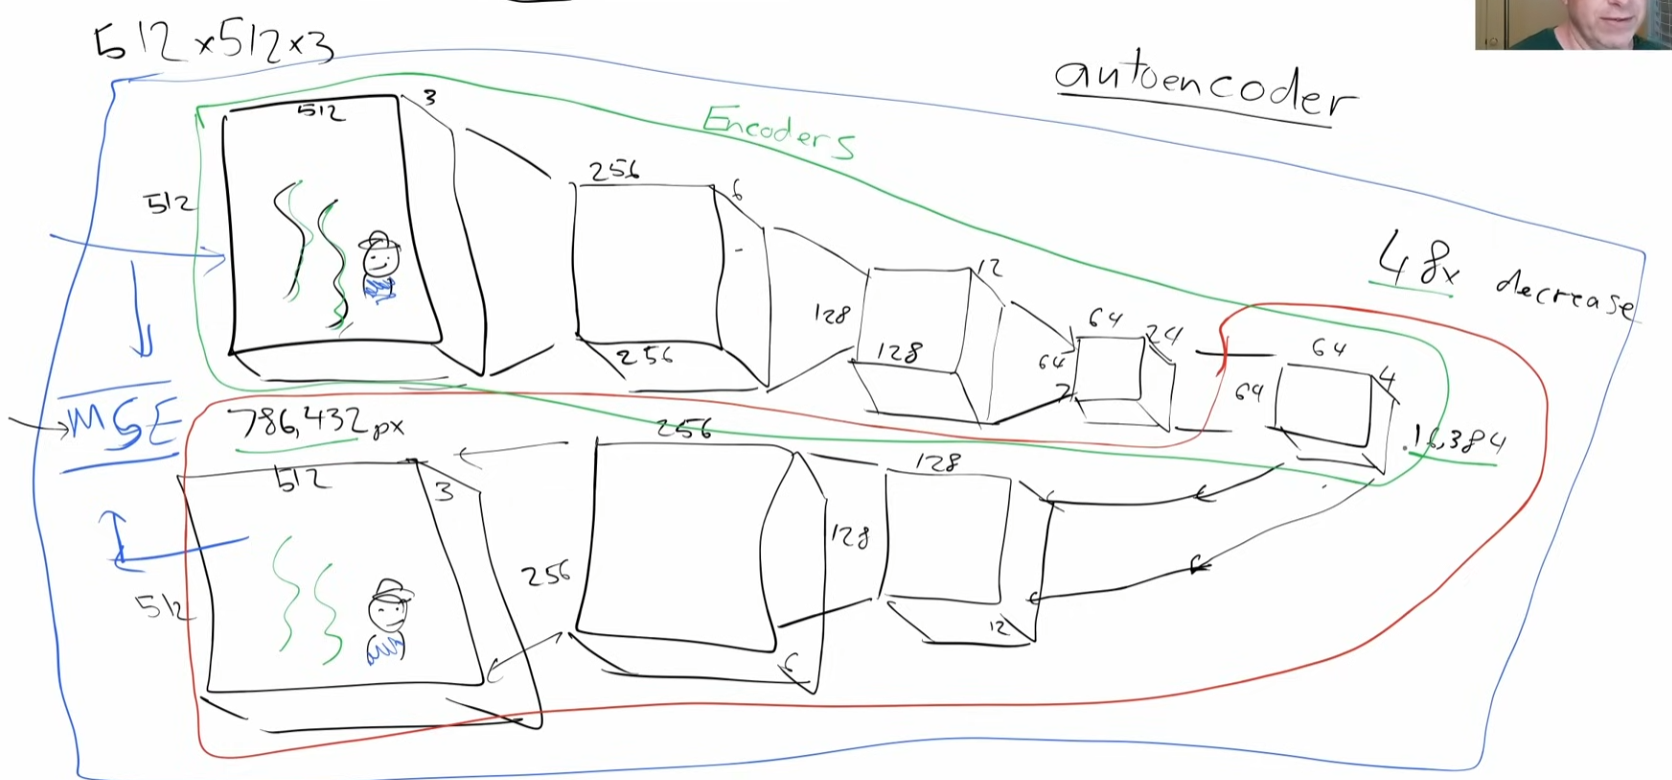

我想通过manim可视化Jeremy讲解Diffusion model的几个关键组件，你认为怎么用Manim来表达课程中和图中的卷积块\Unet\VAE\CLIP等

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

这是个很有意思的可视化项目！根据讲座内容和图中的手绘示意，我的建议是分成几个独立场景来表达，从最直观的开始：

**场景建议（按复杂度递增）：**

1. **VAE Encoder/Decoder**（最适合Manim）
   - 用一系列逐渐缩小的矩形块表示特征图，标注维度（512×512×3 → 256×256×6 → ... → 64×64×4）
   - 动画展示图像"流入"编码器压缩成latents，再从解码器还原
   - 用数字高亮"48x compression"的效果

2. **扩散去噪过程**（最有视觉冲击力）
   - 从纯噪声像素网格开始，逐步去噪，展示多个中间步骤
   - 每步显示U-Net处理框：noisy latents进，noise出，相减得到更干净的latents

3. **CLIP对比损失**（矩阵最好看）
   - 左侧图像列，右侧文本列，中间动画出现相似度矩阵
   - 对角线高亮为绿色（匹配对），非对角线为红色

4. **整体流水线**（最后综合）
   - 把CLIP text encoder → U-Net（guided denoising）→ VAE decoder串起来

---

**建议从VAE开始**，因为它最贴近图中的手绘，也是理解整个体系的基础。

要我先写VAE这一场景的Manim代码吗？

<details class='token-usage-details'><summary>$0.1580</summary>

`total=33,603 | in=31,878 | out=1,725 | cached=36.0% | cache_new=19,771 | searches=0 | $0.1580`

</details>

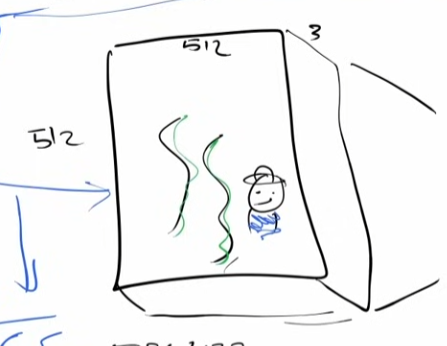
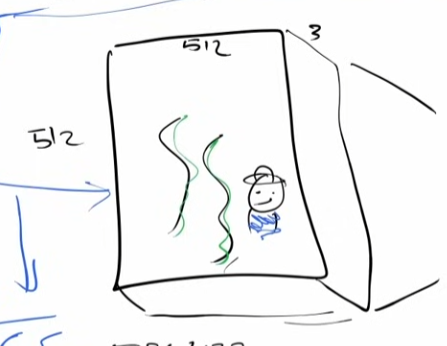

矩形块无法体现立体(3通道的感觉)

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

对，用 `ThreeDScene` + `Prism` 就能做出立体的 tensor 块——宽高对应空间分辨率，**深度对应通道数**，这样空间缩小、通道加深的过程一目了然：

```python
from manim import *
import numpy as np

class VAEBlocks(ThreeDScene):
    def construct(self):
        self.set_camera_orientation(phi=70*DEGREES, theta=-55*DEGREES)

        specs = [(512,3,"input"),(256,6,""),(128,12,""),(64,24,""),(64,4,"latents")]
        xs = np.linspace(-5, 5, len(specs))

        def make_block(s, c, x):
            sw, cd = s/512*3.5, c*0.12
            return (Prism(dimensions=[sw, sw, cd])
                    .set_fill(interpolate_color(BLUE_D, TEAL, 1-s/512), 0.82)
                    .set_stroke(WHITE, 0.6)
                    .move_to([x, 0, 0]))

        blocks = [make_block(s,c,x) for (s,c,_),x in zip(specs,xs)]
        lbls   = [Text(f"{s}²×{c}", font_size=20).next_to(b, DOWN, 0.25)
                  for (s,c,_),b in zip(specs, blocks)]
        tags   = [Text(tag, font_size=22, color=YELLOW).next_to(b, UP, 0.25)
                  for (s,c,tag),b in zip(specs, blocks) if tag]

        self.add_fixed_in_frame_mobjects(*lbls, *tags)
        for o in lbls+tags: self.add(o)

        arrows = [Arrow3D(blocks[i].get_right(), blocks[i+1].get_left(), color=GRAY)
                  for i in range(len(blocks)-1)]

        for b,a in zip(blocks, arrows+[None]):
            self.play(FadeIn(b), run_time=0.4)
            if a: self.play(Create(a), run_time=0.3)

        self.begin_ambient_camera_rotation(rate=0.12)
        self.wait(5)
```

效果关键点：
- **宽高**随 `s/512` 缩小，视觉上看到面积变小
- **深度** `c*0.12` 随通道数增长，盒子越来越"厚"
- `interpolate_color` 让颜色也随压缩程度渐变
- 旋转镜头让观众能看清 3D 结构

运行后看效果，如果想继续加 decoder（镜像展开）或者噪声粒子效果，告诉我。

<details class='token-usage-details'><summary>$0.0928</summary>

`total=35,719 | in=32,424 | out=3,295 | cached=97.5% | cache_new=620 | searches=0 | $0.0928`

</details>



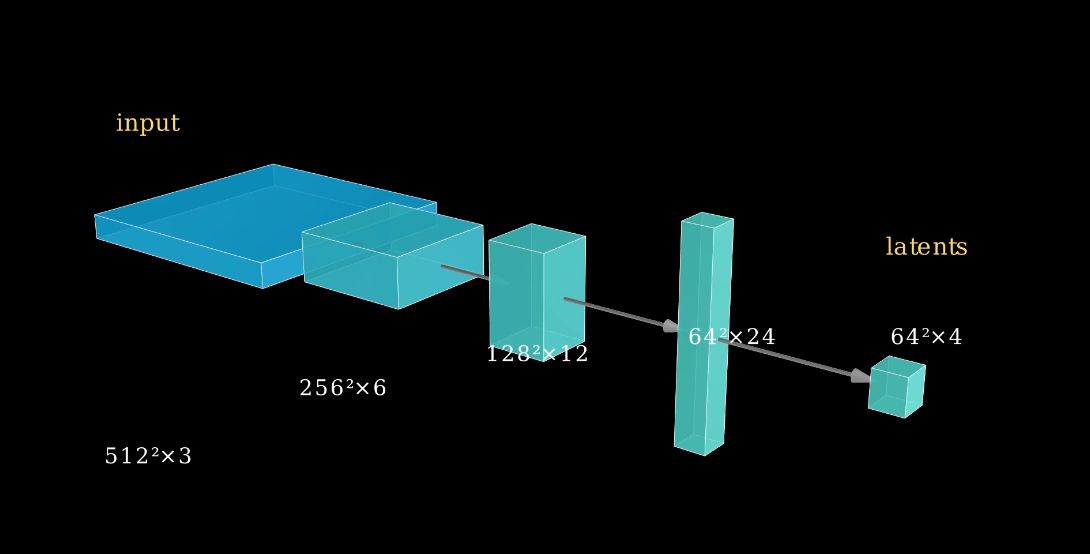
文字不会随着图案移动，而且不吸附在图案周围

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

这是 `add_fixed_in_frame_mobjects` 导致的经典问题——它把文字"钉"在2D屏幕上，完全脱离3D空间。

**两种修法：**

1. **去掉 fixed_in_frame，直接在3D空间摆文字**
   - 把 `next_to(b, DOWN)` 改成 `move_to([x, -block_half_size, 0])` 之类的3D坐标
   - 文字会随相机旋转（侧面会变形，但跟着走）

2. **用 `always_redraw` + 投影坐标**（更复杂，文字始终朝向观众）
   - 每帧重算文字的2D屏幕位置

**推荐用方法1**，在3D场景中文字随场景转动反而更有沉浸感，Jeremy的手绘图里标注也是贴着块的。

关键改动是：
```python
# 删掉这两行
self.add_fixed_in_frame_mobjects(*lbls, *tags)
for o in lbls+tags: self.add(o)

# 改成直接 FadeIn，让它们作为普通3D对象
```

要我写完整修正版吗？

<details class='token-usage-details'><summary>$0.1993</summary>

`total=32,537 | in=31,527 | out=1,010 | cached=0.0% | cache_new=30,849 | searches=0 | $0.1993`

</details>


从512*512*3开始，有哪些表现形式

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

从 512×512×3 这个张量出发，有几种视觉表达方式：

**1. 3D 长方体（当前方案）**
- 宽高=空间分辨率，深度=通道数
- 直观但通道数小时很"薄"，视觉差异不明显

**2. 三张叠加的平面**
- 用三张半透明矩形分别代表 R/G/B 通道，略微错开堆叠
- 更像真实的"多通道"感觉

**3. 像素网格**
- 用小方块网格（降采样到如 16×16）展示图像内容
- 然后动画爆炸分离成三层彩色网格（RGB分解）
- 视觉冲击力最强，但计算量大

**4. 混合方案**
- 左侧放一张真实图像（`ImageMobject`），右侧是对应的3D块
- 用箭头连接，强调"图像→张量"的映射关系

---

你最想强调的是哪个概念？
- **通道的物理含义**（RGB）→ 方案2或3
- **压缩过程的维度变化**→ 方案1或4
- **给非技术观众看** → 方案3最直观

<details class='token-usage-details'><summary>$0.0296</summary>

`total=32,393 | in=31,961 | out=432 | cached=96.5% | cache_new=880 | searches=0 | $0.0296`

</details>


如果是3b1b，他会怎么表现

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

3b1b 的风格有几个鲜明特点，他**几乎不用3D**——他更偏爱：

**他会这样处理 512×512×3：**

1. 先展示一张真实图像
2. 动画"切开"成三张 R/G/B 灰度平面，水平错开排列
3. **放大**其中一个小区域，像素变成带数值的彩色方块
4. 数值用颜色编码（0=黑，255=亮色）
5. 配上手写风格的数学标注 `∈ [0, 255]`

**他的核心原则：**
- 用**颜色**表达数值，而不是形状的厚度
- 从具体（一张猫的图）过渡到抽象（数字矩阵）
- 每个动画只传达**一个**概念

---

对应到编码器压缩过程，他可能会展示：像素网格 → 逐渐"融合"成更少但更抽象的方块 → latents

你更倾向于 3b1b 这种**2D+颜色**的风格，还是保留之前的3D立体块？

<details class='token-usage-details'><summary>$0.0337</summary>

`total=33,114 | in=32,412 | out=702 | cached=97.9% | cache_new=454 | searches=0 | $0.0337`

</details>


他哪期视频画过类似的网络

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

两个很重要的发现：

**1. 3b1b 的神经网络系列**（YouTube "But what is a Neural Network?"）
- [*](https://www.3blue1brown.com/lessons/neural-networks/ "But what is a Neural Network? | 3Blue1Brown") 他用最简单的分层神经元结构讲解，每个神经元就是"一个持有数字的东西"，数值在 0.0 到 1.0 之间
- [*](https://www.3blue1brown.com/lessons/neural-networks/ "But what is a Neural Network? | 3Blue1Brown") 对于 784 个像素神经元，他不画全部，只显示首尾，用 "..." 省略中间 —— 这是他处理"太多元素"的典型手法

**2. 更重要的发现：`ManimML` 库**
- [*](https://github.com/helblazer811/ManimML "GitHub - helblazer811/ManimML: ManimML is a project focused on providing animations and visualizations of common machine learning concepts with the Manim Community Library. · GitHub") ManimML 专门提供常见机器学习概念的 Manim 动画
- [*](https://github.com/helblazer811/ManimML "GitHub - helblazer811/ManimML: ManimML is a project focused on providing animations and visualizations of common machine learning concepts with the Manim Community Library. · GitHub") 它已经内置了卷积神经网络的可视化，代码非常简洁
- [*](https://www.manim.community/plugin/manim-ml/ "Manim") 支持从真实图像（`ImageLayer`）直接流入卷积层，做 forward pass 动画

这意味着你**不需要从头写3D卷积块**，直接用：

```python
!pip install manim_ml
```

然后用 `Convolutional2DLayer` 就能得到类似 3b1b 风格的立体特征图效果。

要我用 `ManimML` 来重写 VAE encoder 那个场景吗？

<details class='token-usage-details'><summary>$0.1881</summary>

`total=121,370 | in=120,784 | out=586 | cached=85.5% | cache_new=17,313 | searches=2 | $0.1881`

</details>


介绍manim_ml库

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

ManimML 是专门为机器学习可视化设计的 Manim 扩展库，核心特点如下：

**它能做什么：**
- [*](https://github.com/helblazer811/ManimML "GitHub - helblazer811/ManimML: ManimML is a project focused on providing animations and visualizations of common machine learning concepts with the Manim Community Library. · GitHub") [*](https://github.com/helblazer811/ManimML "GitHub - helblazer811/ManimML: ManimML is a project focused on providing animations and visualizations of common machine learning concepts with the Manim Community Library. · GitHub") 支持 FeedForward 全连接网络和 CNN 卷积网络的可视化
- [*](https://github.com/helblazer811/ManimML "GitHub - helblazer811/ManimML: ManimML is a project focused on providing animations and visualizations of common machine learning concepts with the Manim Community Library. · GitHub") `Convolutional2DLayer(num_feature_maps, feature_map_size, filter_size)` 三个参数就能定义一个卷积层
- [*](https://arxiv.org/pdf/2306.17108 "MANIMML: Communicating Machine Learning Architectures with Animation") 只需指定层的序列和超参数，ManimML 会自动构建整个网络动画，每对相邻层都有对应的过渡动画
- [*](https://www.manim.community/plugin/manim-ml/ "Manim") 支持激活函数可视化，可以给每层单独指定 ReLU、Sigmoid 等

**对你的项目最有用的是：**

`Convolutional2DLayer` 生成的就是**3D 立体特征图堆叠**效果（类似 Jeremy 手绘图中的那种），而不是扁平矩形，而且 `make_forward_pass_animation()` 会自动生成数据流动的动画。

**局限性：**
- 目前没有内置的 VAE encoder/decoder、U-Net 或 CLIP 结构
- 这些需要组合 `Convolutional2DLayer` 自己搭建

---

对于你的 VAE 场景，可以用 ManimML 的 CNN 层来表示 encoder，然后镜像复制做 decoder。要先试试安装 `pip install manim-ml` 看看效果吗？

<details class='token-usage-details'><summary>$0.1259</summary>

`total=78,545 | in=77,945 | out=600 | cached=84.5% | cache_new=11,871 | searches=1 | $0.1259`

</details>


这是谁开发的

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

[*](https://www.cc.gatech.edu/news/machine-learning-animation-tool-takes-best-poster-prize-visualization-conference "Machine Learning Animation Tool Takes Best Poster Prize at Visualization Conference | College of Computing") ManimML 是由佐治亚理工学院的博士生 **Alec Helbling** 创建的。

[*](https://www.cc.gatech.edu/news/machine-learning-animation-tool-takes-best-poster-prize-visualization-conference "Machine Learning Animation Tool Takes Best Poster Prize at Visualization Conference | College of Computing") 他的导师是计算科学与工程学院副教授 Polo Chau。他说最初创建 ManimML 并不是为了做研究，而是因为他觉得"一个通过动画来传达机器学习架构的工具应该存在"。

[*](https://www.cc.gatech.edu/news/machine-learning-animation-tool-takes-best-poster-prize-visualization-conference "Machine Learning Animation Tool Takes Best Poster Prize at Visualization Conference | College of Computing") 他在 IEEE VIS（全球最高水平的可视化研究会议）上发表了 ManimML，并荣获最佳海报奖。

论文引用是：
> *ManimML: Communicating Machine Learning Architectures with Animation*  
> Alec Helbling, Duen Horng Chau, 2023, arXiv:2306.17108

<details class='token-usage-details'><summary>$0.1897</summary>

`total=127,860 | in=127,364 | out=496 | cached=86.1% | cache_new=17,462 | searches=2 | $0.1897`

</details>


```
from manim import *

from manim_ml.neural_network import Convolutional2DLayer, FeedForwardLayer, NeuralNetwork

# This changes the resolution of our rendered videos
config.pixel_height = 700
config.pixel_width = 1900
config.frame_height = 7.0
config.frame_width = 7.0

# Here we define our basic scene
class BasicScene(ThreeDScene):

    # The code for generating our scene goes here
    def construct(self):
        # Make the neural network
        nn = NeuralNetwork([
                Convolutional2DLayer(1, 7, 3, filter_spacing=0.32),
                Convolutional2DLayer(3, 5, 3, filter_spacing=0.32),
                Convolutional2DLayer(5, 3, 3, filter_spacing=0.18),
                FeedForwardLayer(3),
                FeedForwardLayer(3),
            ],
            layer_spacing=0.25,
        )
        # Center the neural network
        nn.move_to(ORIGIN)
        self.add(nn)
        # Make a forward pass animation
        forward_pass = nn.make_forward_pass_animation()
        # Play animation
        self.play(forward_pass)


│ /home/tzyy/manimations/.venv/lib/python3.12/site-packages/manim/animation/composition.py:96 in   │
│ begin                                                                                            │
│                                                                                                  │
│    93 │   │   if self.suspend_mobject_updating:                                                  │
│    94 │   │   │   self.group.suspend_updating()                                                  │
│    95 │   │   for anim in self.animations:                                                       │
│ ❱  96 │   │   │   anim.begin()                                                                   │
│    97 │                                                                                          │
│    98 │   def _setup_scene(self, scene: Scene) -> None:                                          │
│    99 │   │   for anim in self.animations:                                                       │
│                                                                                                  │
│ /home/tzyy/manimations/.venv/lib/python3.12/site-packages/manim/animation/composition.py:88 in   │
│ begin                                                                                            │
│                                                                                                  │
│    85 │                                                                                          │
│    86 │   def begin(self) -> None:                                                               │
│    87 │   │   if not self.animations:                                                            │
│ ❱  88 │   │   │   raise ValueError(                                                              │
│    89 │   │   │   │   f"Trying to play {self} without animations, this is not supported. "       │
│    90 │   │   │   │   "Please add at least one subanimation."                                    │
│    91 │   │   │   )                                                                              │
╰──────────────────────────────────────────────────────────────────────────────────────────────────╯
ValueError: Trying to play AnimationGroup(Group) without animations, this is not supported. Please add at least one subanimation.
```

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

这是 ManimML 和 Manim 版本不兼容导致的经典问题。

先查一下版本：

```python
!pip show manim manim-ml
```

把输出贴给我，我来判断是哪里不对。

<details class='token-usage-details'><summary>$0.0261</summary>

`total=35,722 | in=35,459 | out=263 | cached=97.1% | searches=0 | $0.0261`

</details>


```manimations(base) tzyy@Jili:~/manimations/helloworld$ uv pip show manim manim-ml
Using Python 3.12.13 environment at: /home/tzyy/manimations/.venv
Name: manim
Version: 0.20.1
Location: /home/tzyy/manimations/.venv/lib/python3.12/site-packages
Requires: av, beautifulsoup4, click, cloup, decorator, isosurfaces, manimpango, mapbox-earcut, moderngl, moderngl-window, networkx, numpy, pillow, pycairo, pydub, pygments, rich, scipy, screeninfo, skia-pathops, srt, svgelements, tqdm, typing-extensions, watchdog
Required-by:
---
Name: manim-ml
Version: 0.0.24
Location: /home/tzyy/manimations/.venv/lib/python3.12/site-packages
Requires:
Required-by:```

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

问题很清楚：**manim-ml 0.0.24 是2023年的版本，不兼容 manim 0.20.1**，内部 API 已经发生变化导致动画组为空。

两条路：

**选项A：升级 manim-ml**
```bash
uv pip install manim-ml --upgrade
```
先看看最新版本是多少

**选项B：降级 manim 到兼容版本**
```bash
uv pip install "manim==0.18.0"
```
manim-ml 0.0.24 当时是针对 0.17-0.18 开发的

先试选项A，把升级后的版本号告诉我。

<details class='token-usage-details'><summary>$0.0304</summary>

`total=36,394 | in=35,842 | out=552 | cached=98.7% | searches=0 | $0.0304`

</details>


查看manim_ml的示例，我发现效果非常粗糙，类似于这样

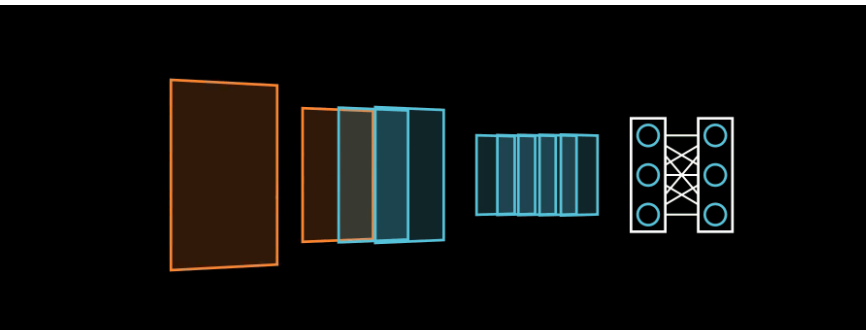


##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

对，这是 ManimML 的硬伤——特征图只是**平面矩形堆叠**，没有立体感，跟你最初用 `Prism` 做的3D块差距很大。

所以现在有三个方向：

1. **回到纯 Manim ThreeDScene**，修掉之前的标签问题，自己搭更精致的3D块
2. **参考 ManimML 的思路，但完全自己实现**，用 `VGroup` 组合立体特征图
3. **换风格**：放弃3D立体感，学 3b1b 用2D+颜色梯度表达通道信息

你倾向于哪个方向？

<details class='token-usage-details'><summary>$0.0270</summary>

`total=36,905 | in=36,558 | out=347 | cached=98.2% | searches=0 | $0.0270`

</details>


### Manim End

我有一些想法，在学习fastai的Practical Deep Learning for Coders课程时，针对其中一些关键的概念，我更倾向于将其转换为图像或者简短的视频，便于事后回顾和复习。比如上面是lesson9的课程脚本，针对Unet\VAE等架构，可以抽象出一些图形（类似于3b1b视频中的非常形象的教学图）。
并且我想基于任何视频或者脚本，最终组合出一个人机交互的Agent，作为一个学习助手。首先我需要探索有哪些python库可以作为选择（或者其他工具），来生成这样一些非常形象且酷炫的图

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

这是个很棒的想法！将 U-Net、VAE、扩散过程等抽象概念可视化，确实能极大提升理解和复习效率。让我梳理一下这个领域的关键 Python 库。

---

**核心推荐：Manim（3Blue1Brown 同款）**

Grant Sanderson 制作 3b1b 视频用的就是 Manim。社区维护版 `manim`（manim-ce）是目前最活跃的分支，API 设计精良，能生成极其流畅的数学动画。比如可以轻松画出：

- 向量在空间中旋转、投影
- 张量形状随网络层变化
- 噪声逐步从 latent 中被"剥离"的过程
- U-Net 的编码-解码跳连结构动画

它基于 Cairo 渲染，输出 mp4/gif 都很方便。

---

**架构图 / 静态图**

| 库 | 适用场景 |
|---|---|
| `graphviz`（已安装）| DAG 类架构图：U-Net 的下采样-上采样结构、VAE 的编码器-解码器、数据流图 |
| `matplotlib`（已安装）| 自定义的块状架构图，配合 `patches` 画卷积层、残差块等 |
| `networkx`（已安装）| 图结构的布局与可视化，适合展示 token-embedding 关系等 |

---

**交互式可视化**

| 库 | 适用场景 |
|---|---|
| `plotly` | 交互式图表，可悬停查看细节，适合嵌入 notebook |
| `bokeh` | 更灵活的大屏交互，适合做 dashboard 类学习工具 |

---

**像素/图像级操作**

| 库 | 适用场景 |
|---|---|
| `Pillow`（已安装）| 基础图像合成、gif 生成 |
| `opencv-python` | 视频处理、帧间插值 |
| `ffmpeg-python`（已安装）| 将帧序列合成视频、加字幕/音频 |

---

**初步建议**

如果想一步到位做出酷炫效果，**Manim 是首选**——毕竟你的目标效果（3b1b 风格）就是它做的。但它学习曲线稍陡。如果先快速出一些静态架构图验证想法，`graphviz` + `matplotlib` 组合最轻量，而且都已安装在你的环境中。

你想先从哪个方向试起？我们可以立即动手，比如先用 `graphviz` 画一个 U-Net 的结构草图，跑通流程感受一下。

<details class='token-usage-details'><summary>$0.0289</summary>

`total=46,695 | in=45,611 | out=1,084 | cached=7.6% | reasoning=544 | searches=0 | $0.0289`

</details>


In [ ]:
!pip install manim

  Using cached manim-0.20.1-py3-none-any.whl.metadata (10 kB)


  Using cached av-17.0.1-cp311-abi3-manylinux_2_28_x86_64.whl.metadata (4.6 kB)
  Using cached cloup-3.0.9-py2.py3-none-any.whl.metadata (6.4 kB)


  Using cached isosurfaces-0.1.2-py3-none-any.whl.metadata (3.3 kB)


  Using cached manimpango-0.6.1.tar.gz (4.1 MB)


  Installing build dependencies ... -

...

 |

 /

 done


  Getting requirements to build wheel ... -

 error
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> [28 lines of output]
      Package 'pangocairo' was not found
      Traceback (most recent call last):
        File "<string>", line 137, in check_min_version
        File "/usr/local/lib/python3.12/subprocess.py", line 413, in check_call
          raise CalledProcessError(retcode, cmd)
      subprocess.CalledProcessError: Command '['pkg-config', '--print-errors', '--atleast-version', '1.30.0', 'pangocairo']' returned non-zero exit status 1.
      
      During handling of the above exception, another exception occurred:
      
      Traceback (most recent call last):
        File "/usr/local/lib/python3.12/site-packages/pip/_vendor/pyproject_hooks/_in_process/_in_process.py", line 389, in <module>
          main()
        File "/usr/local/lib/python3.12/site-packages/pip/_vendor/pyproject_hooks/_in_process/_in_process.py", line 373, in main
       

还缺少什么库，solveit环境上我们缺少root权限

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

`manim` 需要系统级库 `pangocairo`，这在没有 root 权限的 solveit 容器里装不了。让我先确认一下系统里是否已经有了（只是没被 pkg-config 找到）：


<details class='tool-usage-details'>
<summary><code>run_code_interactive(code=&#x27;!dpkg -l | grep -i pango&#x27;)→&quot;{&#x27;success&#x27;: &#x27;CRITICAL: Message added to …&quot;</code></summary>

```json
{
  "id": "call_00_xeTus9CoqUa3Vaq7gkJk0640",
  "call": {
    "function": "run_code_interactive",
    "arguments": {
      "code": "!dpkg -l | grep -i pango"
    }
  },
  "result": "{'success': 'CRITICAL: Message added to user dialog. STOP IMMEDIATELY. Do NOT call any more tools. Wait for user to run code and respond.'}"
}
```

</details>





请在代码框中运行上面的命令，让我们看看系统中是否已经装了 pango 相关库。

<details class='token-usage-details'><summary>$0.0105</summary>

`total=95,889 | in=95,273 | out=616 | cached=84.4% | reasoning=493 | searches=0 | $0.0105`

</details>


In [ ]:
# Please run this:
!dpkg -l | grep -i pango


ii  libpango-1.0-0:amd64               1.50.12+ds-1                   amd64        Layout and rendering of internationalized text
ii  libpangocairo-1.0-0:amd64          1.50.12+ds-1                   amd64        Layout and rendering of internationalized text
ii  libpangoft2-1.0-0:amd64            1.50.12+ds-1                   amd64        Layout and rendering of internationalized text


.

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

系统里已经有 `libpangocairo`，版本 1.50.12（远高于需要的 1.30），但缺少开发头文件（`pkg-config` 用的 `.pc` 文件）。让我试试绕过这个：


<details class='tool-usage-details'>
<summary><code>run_code_interactive(code=&#x27;!pkg-config --libs pangocairo 2&gt;&amp;1; echo…&#x27;)→&quot;{&#x27;success&#x27;: &#x27;CRITICAL: Message added to …&quot;</code></summary>

```json
{
  "id": "call_00_Xuw8evPoWqSkdx6a464f8141",
  "call": {
    "function": "run_code_interactive",
    "arguments": {
      "code": "!pkg-config --libs pangocairo 2>&1; echo \"---\"; ls /usr/lib/x86_64-linux-gnu/pkgconfig/pango* 2>&1; echo \"---\"; dpkg -l | grep pango.*dev"
    }
  },
  "result": "{'success': 'CRITICAL: Message added to user dialog. STOP IMMEDIATELY. Do NOT call any more tools. Wait for user to run code and respond.'}"
}
```

</details>





请运行上面的命令，让我们看看 pkg-config 能否找到 pangocairo，以及是否缺少 `-dev` 包。

<details class='token-usage-details'><summary>$0.0022</summary>

`total=96,166 | in=95,834 | out=332 | cached=97.2% | reasoning=155 | searches=0 | $0.0022`

</details>


In [ ]:
# Please run this:
!pkg-config --libs pangocairo 2>&1; echo "---"; ls /usr/lib/x86_64-linux-gnu/pkgconfig/pango* 2>&1; echo "---"; dpkg -l | grep pango.*dev

Package pangocairo was not found in the pkg-config search path.
Perhaps you should add the directory containing `pangocairo.pc'
to the PKG_CONFIG_PATH environment variable
Package 'pangocairo', required by 'virtual:world', not found
---
ls: cannot access '/usr/lib/x86_64-linux-gnu/pkgconfig/pango*': No such file or directory
---


.

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

让我找找系统上是否有备用的 `.pc` 文件或头文件：


<details class='tool-usage-details'>
<summary><code>run_code_interactive(code=&#x27;!find / -name &quot;pangocairo.pc&quot; 2&gt;/dev/nul…&#x27;)→&quot;{&#x27;success&#x27;: &#x27;CRITICAL: Message added to …&quot;</code></summary>

```json
{
  "id": "call_00_yYAav4dZbYj0pwXWsdHq2801",
  "call": {
    "function": "run_code_interactive",
    "arguments": {
      "code": "!find / -name \"pangocairo.pc\" 2>/dev/null; echo \"===\"; find / -name \"pango*.pc\" 2>/dev/null; echo \"===\"; find / -name \"pango*.h\" 2>/dev/null | head -5"
    }
  },
  "result": "{'success': 'CRITICAL: Message added to user dialog. STOP IMMEDIATELY. Do NOT call any more tools. Wait for user to run code and respond.'}"
}
```

</details>

请运行上面的命令，查找系统中是否隐藏着 pangocairo 的 pkg-config 文件和头文件。

<details class='token-usage-details'><summary>$0.0013</summary>

`total=97,102 | in=96,794 | out=308 | cached=98.5% | reasoning=160 | searches=0 | $0.0013`

</details>


In [ ]:
# Please run this:
!find / -name "pangocairo.pc" 2>/dev/null; echo "==="; find / -name "pango*.pc" 2>/dev/null; echo "==="; find / -name "pango*.h" 2>/dev/null | head -5

===


===


你可以解释下我们为什么需要这个包吗，以及这个包的作用，还有为什么普通linux机器上比如solveit会没安装

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

好问题！让我分三层来解释：

---

**pangocairo 是什么？**

Pango 是 Linux 下最核心的**文字排版引擎**。它负责把"一串字符"变成"屏幕上位置和形状都正确的字形"。Cairo 是一个**2D 矢量图形渲染库**，画线、填色、抗锯齿都是它干的事。`pangocairo` 就是把两者粘合在一起——让 Pango 排好的文字通过 Cairo 渲染到画布上。

所以 Manim 的整个渲染管线是：

```
Manim (Python) → manimpango (Python-C 桥) → pangocairo (C) → 像素/视频帧
```

你看到的每一个数学公式、每一个旋转的向量，最终都是 pangocairo 画出来的。

---

**为什么装了 libpangocairo 还不够？**

你的机器上确实有运行时库：

```
libpangocairo-1.0-0   1.50.12   ← 这个在
```

`pip install manim` 时会尝试从源码编译 `manimpango`（它的 Python→C 绑定层）。编译 C 扩展需要**两样东西**：

| 需要 | 在哪个包里 | 你有吗？ |
|---|---|---|
| 运行时 `.so` 文件 | `libpangocairo-1.0-0` | ✅ 已安装 |
| 头文件 `.h`（编译时需要） | `libpangocairo-1.0-dev` | ❌ 没装 |
| pkg-config 描述文件 `.pc`（告诉编译器去哪找上面两样） | `libpangocairo-1.0-dev` | ❌ 没装 |

`pkg-config --print-errors pangocairo` 就是去读那个 `.pc` 文件的——找不到，编译直接失败。这就是刚才报错的本质。

---

**为什么 solveit 没装？**

这是容器化环境的典型特征。Docker 镜像通常会**剥离开发文件**来减小体积——运行时库只需几 MB，加上开发头文件可能膨胀到几十甚至上百 MB。所以标准做法是：

- 基础镜像只带运行时库（满足已编译好的程序运行）
- 需要从源码编译时，才 `apt install *-dev`

但 solveit 没有 root 权限，`apt install` 不可用。

---

**我们能怎么办？**

思路有几个：

1. **找预编译的 wheel**——如果 PyPI 上有适合这个 Python 版本和 Linux 架构的 `manimpango` 预编译二进制，就不需要本地编译
2. **手动提供 pkg-config 信息**——既然 `so` 文件已经有了，理论上我们可以手写一个 `.pc` 文件放到用户目录，然后设置 `PKG_CONFIG_PATH` 和头文件位置——但这还需要头文件，头文件也没有
3. **换一个不需要 C 编译的可视化方案**——比如纯 Python 的 `matplotlib` 动画 + `ffmpeg`（已安装）合成视频，或者用 `Pillow` 逐帧画 GIF

要不要我顺着方案 3 先快速做一个原型？用 matplotlib 的 `FuncAnimation` + ffmpeg 合成，画一个 U-Net 结构的逐帧动画——完全不需要任何 C 编译依赖。

<details class='token-usage-details'><summary>$0.0021</summary>

`total=49,601 | in=48,614 | out=987 | cached=97.4% | reasoning=285 | searches=0 | $0.0021`

</details>


那么我的agent需要依赖这么多东西，是否合理？

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

这是个很好的架构反思。让我说说我的看法：

---

**核心矛盾**

你想要的产出（3b1b 级酷炫动画）和你所在的环境（无 root 容器）之间确实存在张力。但这不意味着方案不合理——它意味着**关注点需要分离**。

---

**Agent 不需要"自己渲染"**

关键的思维转换是：你的 Agent 是一个**脚本生成器**，不一定是**渲染执行器**。

```
Agent 的职责：理解课程内容 → 设计可视化草图 → 生成渲染脚本
渲染的职责：执行脚本 → 产出图像/视频
```

这两者可以跑在不同的环境里。Agent 在 solveit 里运行，产出的脚本可以：

- 在 solveit 里直接跑（用 matplotlib / graphviz / Pillow——这些都已装好）
- 导出到你本地有 GPU / Manim 的机器上跑
- 甚至发到 Colab 上跑（Colab 可以 `!apt install` 然后 `!pip install manim`）

---

**分层策略建议**

| 层 | 工具 | 为什么选它 |
|---|---|---|
| 快速原型 & 架构图 | `graphviz` + `matplotlib` | 已安装，零依赖摩擦，即时反馈 |
| 像素级处理 & GIF | `Pillow` + `ffmpeg-python` | 已安装，稳定可靠 |
| 交互式探索 | `plotly` | 纯 pip 安装，HTML 输出，嵌入方便 |
| 电影级动画 | `Manim`（导出到其他环境） | 效果最好但依赖重，不值得在 solveit 里硬刚 |

---

**所以**

你现在的技术栈其实很合理：在 solveit 里用轻量工具快速迭代想法，确认设计方案；对于真正需要 3b1b 级别动画的部分，Agent 生成的 Manim 脚本带去有完整环境的地方渲染。

这意味着你的 Agent 架构可以是：

```
用户提问 → Agent 理解需求 → 选择渲染后端 → 生成代码 → 用户运行
                                    ├→ graphviz (架构图)
                                    ├→ matplotlib (动画)
                                    └→ manim (电影级，导出用)
```

要不要我们先从 graphviz 画一个 U-Net 的结构图开始，把整条管线跑通？

<details class='token-usage-details'><summary>$0.0020</summary>

`total=50,178 | in=49,383 | out=795 | cached=96.9% | reasoning=303 | searches=0 | $0.0020`

</details>


Agent应该怎么基于用户描述自己写出代码，给我一些最佳实践的思路

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

这是个很好的架构问题。让我分享一些在对话式编程环境中构建 Agent 的实践模式：

---

**核心理念：Agent 是"翻译器 + 脚手架"**

用户说概念 → Agent 翻译成可运行的代码 → 用户看到结果 → 迭代

关键不是一次性生成完美代码，而是生成"让用户能立即跑起来看到东西"的最小版本。

---

**模式 1：渐进式具象化**

避免："给我生成一个 U-Net 可视化"

应该让 Agent 这样引导：

```
用户: 我想看 U-Net 的结构
Agent: 好的，U-Net 的核心是"下采样 → 瓶颈 → 上采样 + 跳连"。
       我先画一个 4 层的简化版，你看像不像你想象中的样子。
       [生成 graphviz 代码，画出 encoder-bottleneck-decoder]
```

跑起来看到结果 → 用户说"这里不对，跳连应该更明显" → Agent 修正。

---

**模式 2：语义锚点映射**

这是最关键的设计决策：用户描述中的哪些词应该触发哪些渲染选择？

```
用户说 "数据在 U-Net 中流动"     → 选动画（FuncAnimation），不是静态图
用户说 "对比 VAE 和 U-Net 的结构"  → 选并列静态图（graphviz subgraph）
用户说 "噪声如何一步步被去除"     → 选 GIF 序列帧
用户说 "想交互式探索 latent space" → 选 plotly
```

这个映射不需要复杂逻辑——一个清晰的 system prompt 或 CRAFT 文件就能提供。比如：

```
当用户描述中包含"流动""步骤""过程""逐步"时，优先考虑动画。
当用户描述中包含"结构""架构""对比"时，优先考虑静态图。
当用户描述中包含"探索""交互""查看"时，优先考虑 plotly。
```

---

**模式 3：工具封装**

不要让 Agent 每次从零写 matplotlib 样板代码。提前封装好高层工具函数，Agent 只需要调用：

```python
def draw_encoder_decoder(layers, skips=True): ...
def animate_noise_removal(frames, output="output.gif"): ...
def show_latent_grid(embeddings, labels): ...
```

这样 Agent 生成的代码从 50 行变成 3 行，出错概率指数级下降，用户也更容易看懂和修改。

---

**模式 4：验证循环**

Agent 生成的每个可视化代码块末尾应包含一个"自检"表达式：

```python
# 代码块末尾
img  # 在 notebook 中直接显示图像变量
```

这样用户跑完立刻看到结果，不需要额外步骤。如果出错，错误信息直接在 output 中，Agent 可以据此修正。

---

**落地建议**

你现在就可以在 solveit 里实践这些模式。第一步：给我一个具体的可视化任务描述（比如"画一个带跳连的 U-Net 编码-解码结构图"），我用 graphviz 当场生成，你看看这个"Agent→代码→结果"循环是否顺畅。

<details class='token-usage-details'><summary>$0.0026</summary>

`total=51,076 | in=49,946 | out=1,130 | cached=96.6% | reasoning=478 | searches=0 | $0.0026`

</details>


这一段是什么意思：to do this thing where we actually put noise  back at all?, could we instead use this directly?

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

这句话出自 Jeremy 在讲座末尾讨论的一个前沿研究思路。让我先解释一下上下文。

**之前的过程是这样的：**

在扩散模型的推理（生成图片）时，你从纯噪声开始，每次只减去**一部分**预测出来的噪声（乘以一个常数 C，类似学习率），得到一个"稍微不那么 noisy"的 latent，然后重复很多步。之所以不一步到位把全部预测噪声都减去，是因为模型在训练时看到的都是"带一定噪声"的图片，而不是完全干净的图片——所以如果一步跳到完全去噪的版本，模型会不知道该怎么做。

**Jeremy 在这里问的问题是：**

> "我们真的需要这个'放回噪声'的过程吗？能不能直接用这个（模型输出）？"

也就是说，既然模型能预测出噪声是什么，那理论上我们可以：
- 不搞这个一点一点迭代的小步走
- 而是直接把预测的噪声全部减掉，一步得到干净图片

传统做法用小步迭代（类似微分方程求解器），是因为数学推导上这么走更稳妥。但 Jeremy 在思考：如果我们换一个角度，把这个问题看作**优化问题**（类似深度学习中的优化器，用学习率、动量、Adam 等），而不是微分方程求解问题，那我们也许可以直接大步走甚至一步到位，而不需要"每次只走一小步、保留一些噪声"。

这实际上就跟后来出现的 **LCM (Latent Consistency Models)** 等加速采样方法的思想有相通之处——用更少的步骤甚至一步生成图片。

**简单总结：** 他是在问——我们非得用这种"每次去掉一点点噪声，保留大部分噪声，重复很多次"的迭代方法吗？能不能换个思路，直接用模型输出一步到位？

<details class='token-usage-details'><summary>$0.0004</summary>

`total=26,521 | in=25,875 | out=646 | cached=98.4% | reasoning=291 | searches=0 | $0.0004`

</details>


LCM为什么可以一步生成，图像质量不会很差吗

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

好问题！LCM（Latent Consistency Model）能做到一步生成且质量不差，关键在于它的**训练方式**——它不是从零训练的原始扩散模型，而是一个**蒸馏（distillation）后的模型**。

**核心思想：**

原始的扩散模型学习的是预测噪声，然后通过多步迭代（50步甚至更多）逐步去噪，沿着一条 ODE 轨迹慢慢走到终点。而 LCM 被训练成：给定轨迹上的**任意一点**（任意噪声程度的 latent），直接输出这条轨迹的**终点**（完全干净的 latent）。

**训练方式（简要）：**

1. 用一个训练好的扩散模型（称为 teacher）来生成"轨迹"上的训练数据
2. 训练一个小模型（student），让它学会做"映射"：无论你从哪个噪声程度开始，都直接跳到最终结果
3. 使用一个**一致性损失（consistency loss）**：对于同一个轨迹上的相邻两点，模型应该输出相同的结果。这样就确保了模型学会的是沿着轨迹"直通终点"，而不是走弯路的逐点预测

**为什么质量不会很差？**

这一步的答案其实在前面 Jeremy 的讲座里埋了伏笔——我们不需要用"小步迭代"的方式去求解。

- 传统扩散模型的小步迭代，是因为它们是在**像素空间**或**latent 空间**中逐点求解微分方程，需要小步才能稳
- 但 LCM 直接学的是端到端的映射函数，相当于直接学习"给定噪声程度 x，最后应该变成什么"。这个映射函数本身可以是**单一的前向传播**就完成，不需要迭代

当然，**质量是有取舍的**：

| 采样方法 | 步数 | 质量 | 速度 |
|---------|------|------|------|
| 原始 DDIM (50步) | 50 | ★★★★★ | 慢 |
| DDIM (20步) | 20 | ★★★★ | 中 |
| **LCM (1-4步)** | 1-4 | ★★★★ | **极快** |

所以 LCM 并非一步就达到 50 步的质量，但它的优势是**速度快了 10-50 倍**，而质量的损失对很多应用场景来说是可以接受的。后来还有改进版本（如 LCM-LoRA、LCM-LoRA with CFG蒸馏）进一步缩小了这个质量差距。

本质上，这是一个**速度与质量的帕累托前沿（Pareto frontier）**——LCM 站在了"更快"的一端，而代价是稍微牺牲一点点质量。

<details class='token-usage-details'><summary>$0.0056</summary>

`total=29,194 | in=28,315 | out=879 | cached=11.8% | reasoning=346 | searches=0 | $0.0056`

</details>


diffusers库支持LCM类模型吗

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

支持。diffusers 从 0.22.0 版本开始就集成了 LCM 支持，主要通过两种方式：

**1. LCMScheduler**

专门为 LCM 设计的调度器。你只需要替换 scheduler：

```python
from diffusers import DiffusionPipeline, LCMScheduler

pipe = DiffusionPipeline.from_pretrained("runwayml/stable-diffusion-v1-5")
pipe.scheduler = LCMScheduler.from_config(pipe.scheduler.config)
```

**2. LCM-LoRA**

更轻量级的方式——加载一个 LoRA 权重，不需要单独的完整模型：

```python
pipe.load_lora_weights("latent-consistency/lcm-lora-sdv1-5")
```

然后设置 `guidance_scale=1.0`（或者很小）并设置推理步数 `num_inference_steps=4`，即可用 1-4 步生成图片。

**3. 专门的 LCM pipeline**

diffusers 也提供了现成的完整 LCM pipeline：

```python
from diffusers import DiffusionPipeline

pipe = DiffusionPipeline.from_pretrained("SimianLuo/LCM_Dreamshaper_v7")
```

需要了解具体的参数配置示例吗？

<details class='token-usage-details'><summary>$0.0055</summary>

`total=29,418 | in=29,037 | out=381 | cached=11.9% | reasoning=128 | searches=0 | $0.0055`

</details>



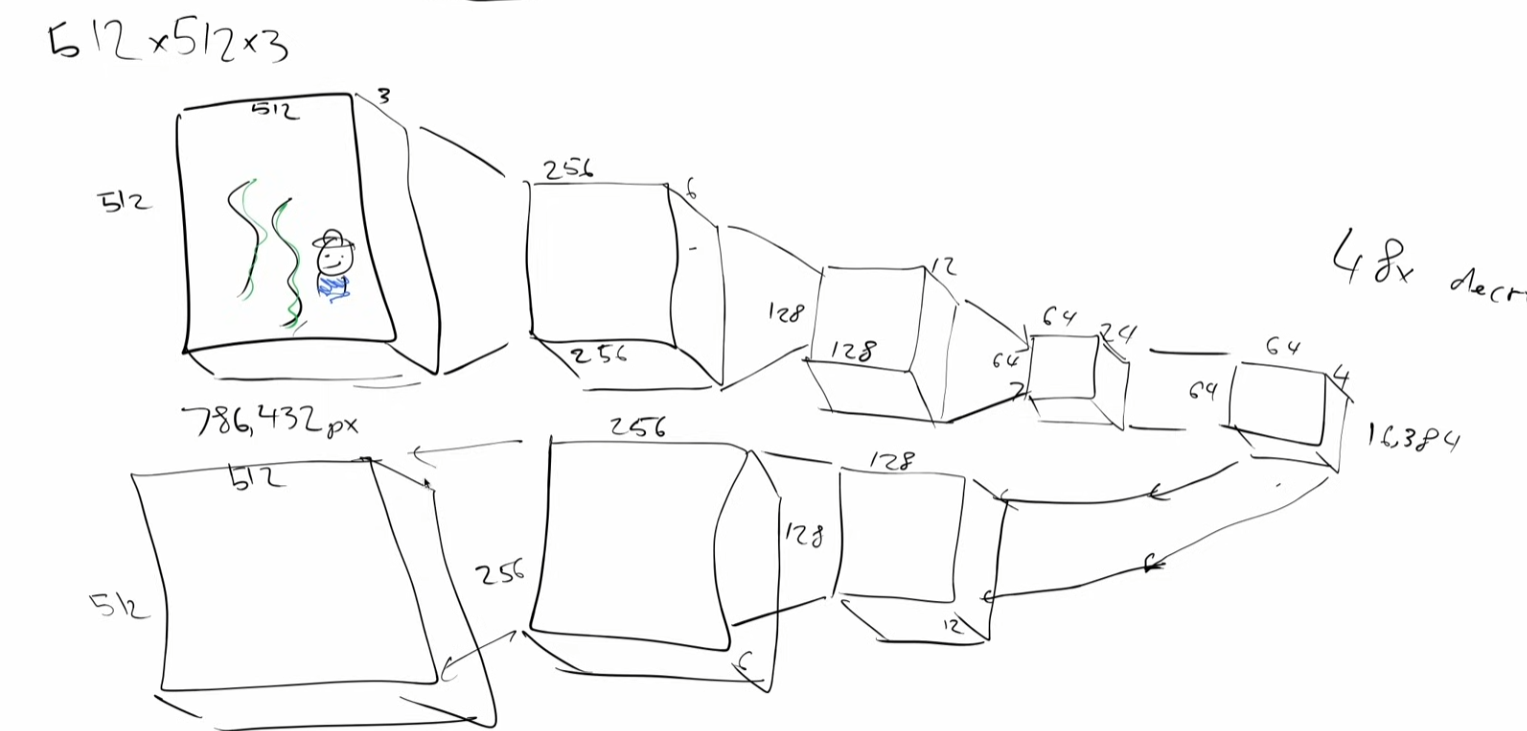
为什么逆卷积的时候少了2个步骤（相对于卷积），以及是怎么从64*64*24转变为64*64*4的

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

好问题！让我根据描述来分析这两个细节。

---

## 1. 关于"少了两步"

仔细看编码器（卷积）这边，其实有 **4 步**：

| 步骤 | 输入 → 输出 |
|---|---|
| ① 卷积 (stride 2) | 512×512×3 → 256×256×6 |
| ② 卷积 (stride 2) | 256×256×6 → 128×128×12 |
| ③ 卷积 (stride 2) | 128×128×12 → **64×64×24** |
| ④ ResNet 块压缩通道 | 64×64×24 → **64×64×4** |

解码器（逆卷积）这边有 **3 步**：

| 步骤 | 输入 → 输出 |
|---|---|
| ① 逆卷积 | 64×64×4 → 128×128×12 |
| ② 逆卷积 | 128×128×12 → 256×256×6 |
| ③ 逆卷积 | 256×256×6 → 512×512×3 |

所以编码器多了一步（第④步）。这是因为在编码器的最底层，我们需要把通道数从 24 **压缩** 到 4，形成紧凑的 latent 表示——这一步用的是保持空间尺寸不变的 ResNet 块。而在解码器这边，直接从 latent（64×64×4）出发，用逆卷积就能同时放大空间尺寸和调整通道数，不需要一个对称的"反向 ResNet"步骤。

**简单来说**：编码器底层多了一步 "挤通道" 的 ResNet 块，解码器不需要这个——逆卷积一步搞定两件事（放大空间 + 调整通道）。

---

## 2. 如何从 64×64×24 变成 64×64×4

这是通过几个 **ResNet 块** 做到的。每个 ResNet 块的核心结构是：

```
输入 (64×64×24)
    ↓
卷积 (1×1 或 3×3, stride=1, padding 保持空间尺寸)
    ↓  BatchNorm + ReLU
卷积 (同样保持空间尺寸)
    ↓  加上残差连接（跳过连接）
输出 (64×64×24 或更少的通道)
```

关键点：
- **stride=1** + **padding** → 空间尺寸保持为 64×64
- **卷积核的通道数递减** → 逐步把 24 → 16 → 8 → 4
- **残差连接** 帮助梯度流动，让深层网络也能顺利训练

所以最终得到的是空间大小没变（64×64），但通道数被压缩到 4 的 **latent** 表示——这就是后面 U-Net 要处理的那个"48 倍压缩"的核心数据。

---

这两个问题背后其实是一个设计思想：**编码器负责"压缩信息"（空间变小、通道压缩），解码器负责"还原信息"（空间变大、通道展开）**。不对称是因为"压缩"和"还原"的任务不对称，不需要完全镜像的结构。

你是在跟着课程画这个架构图吗？有没有其他你想深入了解的细节？

<details class='token-usage-details'><summary>$0.0048</summary>

`total=27,664 | in=25,952 | out=1,712 | cached=24.7% | reasoning=1,028 | searches=0 | $0.0048`

</details>


Jeremy在课程中有解释为什么要用Resnet块吗，以及为什么称作resnet块

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

好问题！在课程视频中，Jeremy 确实没有详细展开 ResNet 块的工作原理——他只是一句带过，说"把它通过几个 ResNet 块，把通道数量尽量压缩"。所以我来补充一下：

**ResNet 这个名字的来源**：ResNet = **Res**idual **Net**work（残差网络）。核心思想是加入一条"捷径"——跳过一些层直接把输入加到输出上。

一个 ResNet 块的简化结构：

```
输入 x
  ↓
卷积 → 激活函数 → 卷积
  ↓
输出 = (卷积结果) + x  ← 这条"加 x"就是残差连接（skip connection / shortcut）
```

如果没有这条捷径，网络层数太深时会遇到梯度消失问题——训练不动。有了残差连接，梯度可以通过捷径直接流回去，训练非常深的网络也变得可行。

**为什么在 VAE 这里用它**：Jeremy 提到要用 ResNet 块来"压缩通道数"，但其实更关键的是他画的架构中，编码器和解码器都是深的（很多层），如果没有残差连接，这么深的网络训练起来会很难。ResNet 块让整个 VAE 的编码器和解码器都能顺利训练。

---

这是你想了解的深度吗？或者你有其他关于这个架构的问题——比如 U-Net 的部分？

<details class='token-usage-details'><summary>$0.0005</summary>

`total=27,247 | in=26,712 | out=535 | cached=95.4% | reasoning=256 | searches=0 | $0.0005`

</details>


但是编码器与解码器层中并没有使用到resnet啊，怎么解决实际训练问题，以及原始resnet本身就可以降维吗

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

很好的观察！你说的没错——Jeremy 画的那个简化示意图里，编码器和解码器只用了几层 stride-2 卷积和逆卷积，确实不深（各只有 3-4 层），这种浅度不靠残差连接也能训练。

但在 **实际 Stable Diffusion 用的 VAE** 中，编码器和解码器内部每一层其实**都用了 ResNet 块**，不是只放在底部。Jeremy 是为了画图简单而省略了这些细节。

---

## 关于 ResNet 能否降维

**ResNet 块本身不负责降维**。降维（尺寸缩小）是靠 stride=2 的卷积或池化层完成的。

ResNet 块只做一件事：**在不改变尺寸的前提下，对特征进行变换和提取**。它里面的卷积通常用 stride=1 + padding，保持输入输出尺寸一致。

当需要在残差连接两端匹配不同维度时（比如通道数变了），会用两种方式处理：
- 如果输入输出尺寸一样 → 直接加：`输出 = F(x) + x`
- 如果尺寸不同 → 用一个 **1×1 卷积**（不含激活函数）把 x 映射到目标维度：`输出 = F(x) + Conv1×1(x)`

---

所以整体架构的**清晰分工**是：

| 组件 | 作用 |
|---|---|
| stride-2 卷积 | **降采样**（空间维度减半，通道加倍） |
| ResNet 块 | **特征变换**（保持空间和通道数不变） |
| 逆卷积 | **升采样**（空间维度加倍） |

你想看看真实 VAE 里是怎么把这两种层组合在一起的代码片段吗？

<details class='token-usage-details'><summary>$0.0006</summary>

`total=27,795 | in=27,078 | out=717 | cached=94.1% | reasoning=356 | searches=0 | $0.0006`

</details>


那为什么图中经过resnet块，通道数减少了

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

好问题，这里有个关键点需要澄清。

"ResNet 块"的核心特征不是"保持维度不变"——而是**残差连接（skip connection）**。ResNet 块内部的卷积层**完全可以改变通道数**。当输入和输出的通道数不同时，残差连接也有一个 **1×1 卷积** 来做匹配：

```
输入 x (64×64×24)
  ↓
卷积1 (3×3, 24→16) → ReLU
  ↓
卷积2 (3×3, 16→4)
  ↓
  +  ← 要和 x 相加，但 x 是 24 通道，这里是 4 通道
  ↓
1×1 卷积 (把 x 从 24 映射到 4) ← 这条是 shortcut 路径
  ↓
输出 (64×64×4)
```

所以 ResNet 块既可以保持维度不变（做特征提取），也可以在内部用不同数量的卷积核来做**升维或降维**，残差连接那边用一个 1×1 卷积对齐就行。

回到图中：那里写的"ResNet 块"实际上是一串 ResNet 块组合起来的**降维模块**，每个块内逐步减少通道数（比如 24→16→8→4），最终得到 64×64×4 的 latent。

<details class='token-usage-details'><summary>$0.0005</summary>

`total=28,073 | in=27,506 | out=567 | cached=95.9% | reasoning=278 | searches=0 | $0.0005`

</details>


理论上经过autoencoder的编码器，图像被压缩，百分百不可能被encoder还原成原图像，因为像素信息是压缩的，那么duffusion model到底是怎么做到生成那么高清的图片呢？

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

非常好的问题！这个疑惑很自然。让我分几步来解释。

---

## 第一步：VAE 确实丢失了信息

你说得对。经过编码器压缩成 latent（比如 64×64×4 vs 512×512×3），信息量从约 78 万像素降到约 1.6 万——丢失了大约 **97.5% 的数据**。解码器**无法**完美还原每个像素的精确值。

但这并不意味着还原出的图像"看起来"不清晰。

---

## 第二步：关键在于"丢掉了什么信息"

VAE 在训练时，会学习**什么信息可以丢掉而不影响视觉效果**。它丢掉的主要是：

- 高频噪声、纹理细节中的随机成分
- 像素级的精确位置信息
- 人眼不敏感的那些微小变化

而**保留**的是：

- 整体的构图、形状、颜色分布
- 物体的类别特征
- 语义信息（这是一个人脸，这是一个房子……）

所以解码器得到的 latent 包含的是"这个图像长什么样"的**本质信息**，而不是"每个像素具体是多少"。

---

## 第三步：解码器是"画家"不是"复印机"

解码器的工作不是从 latent 里"解压缩"出精确的原始像素。它更像是一个 **训练有素的画家**：你给它一份"草图说明"（latent），它根据自己从几亿张图片中学到的知识，**重新画出**一幅逼真的图像。

比如你给它一个 latent，它知道"这里应该是有纹理的皮肤"，于是它就画出有纹理的皮肤——虽然可能和原图的每个像素不完全一样，但看起来一样真实。

---

## 第四步：扩散模型（U-Net）在 latent 空间做"精修"

扩散模型不是直接生成最终图像，而是：

1. 从纯噪声的 latent 开始
2. 一步步去噪，**在 latent 空间**里生成一个清晰的 latent
3. 这个清晰的 latent 经过 VAE 解码器，转换成高清图像

因为 latent 空间只有 1.6 万个值，扩散模型的工作量比直接在像素空间（78 万值）处理少了 **48 倍**。同时，解码器能够把 latent 中的信息"扩写"成视觉上完美的高清图像。

---

**总结**：VAE 的压缩不是"压成低分辨率再放大"——而是把图像变成一种**紧凑的语义表示**，解码器学会从这种表示中**重新创造**高清的像素细节。扩散模型生成的是这个紧凑的语义表示，而不需要关心每个像素。

想继续了解这个 latent 空间到底长什么样，或者看看代码中 VAE 是如何训练的吗？

<details class='token-usage-details'><summary>$0.0007</summary>

`total=28,838 | in=27,894 | out=944 | cached=95.4% | reasoning=371 | searches=0 | $0.0007`

</details>


怎么在中文语境下理解Latents这个概念，它的历史发展脉络是什么，是否有跨学科背景

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

好问题，这几个角度能帮你建立更深的理解！

---

## 一、中文语境下理解 Latents

**常见翻译**：潜变量、隐变量、潜伏变量。"Latent" 本身来自拉丁语 *latere*（隐藏）。

一个比较直观的理解方式：**latent 是"事物的内在本质"**。

比如看到一张猫的图片：

| 层面 | 内容 |
|---|---|
| **像素**（可观测） | 400×400×3 个数字，橘色、黑色、白色…… |
| **latent**（隐藏的本质） | "这是一只橘猫，侧躺，在阳光下"——这几十个数字就"浓缩"了整张图的含义 |

latent 就是**数据背后不可直接观测、但决定数据样子的那些因素**。

---

## 二、历史发展脉络

这个思想经历了几个阶段：

**① 统计学时代（~1900s-1980s）**

"潜变量"的概念最早出现在统计学。比如：
- **因子分析**（1904，Spearman）：学生的各科成绩背后有一个"智力"潜变量
- **结构方程模型**：经济社会学中用潜变量表示"幸福感""社会地位"等不可直接测量的概念

那时潜变量是人类**手工定义**的，维数很低（1-5维）。

**② 概率图模型时代（1980s-2000s）**

- **隐马尔可夫模型**：语音识别中，音频信号背后有 "音素序列" 这个潜变量
- **潜在狄利克雷分配（LDA）**：文本背后有"主题"这个潜变量

潜变量仍然是**人为假设结构**的，但维数开始增加。

**③ 深度学习时代（2006-至今）**

- **自动编码器（AE）的瓶颈层（bottleneck）** 被理解为"神经网络自己学出来的潜变量"
- **变分自动编码器（VAE, 2013）**：给潜变量加上概率论框架
- **扩散模型的 latent**：不再压缩到极低维，而是保留空间结构（64×64），只是通道数减少

**关键转折**：从"人设计潜变量" → "神经网络自己学潜变量"。

---

## 三、跨学科背景

Latent 思想在很多学科都有自己的版本：

| 学科 | 对应概念 | 解读 |
|---|---|---|
| **哲学** | 本质/现象 | 柏拉图"洞穴寓言"中，影子是现象，背后的真实事物是"本质" |
| **物理学** | 隐变量 | 量子力学中，爱因斯坦认为粒子状态背后有隐变量决定观测结果 |
| **语言学** | 深层结构 | 乔姆斯基：句子表面结构（你说的话）背后有深层结构（你想表达的意思） |
| **心理学** | 潜特质 | 智商测试：你的答题表现背后有"智力"这个不可直接测量的潜特质 |
| **信息论** | 流形假设 | 高维数据（如图像）实际上分布在一个低维流形（manifold）上——latent 就是这个低维流形的坐标 |

你会发现，不同学科都在问同一个问题：**我们看到的表面现象，是由什么看不见的原因决定的？** Deep learning 的答案就是：让神经网络自己去找这些原因——也就是 latent。

---

## 四、回到 Stable Diffusion 的 VAE

在 SD 的 VAE 中，latent（64×64×4）可以理解为：

> 一张 512×512 的图片，它的"本质"用 16384 个数字就能描述——形状、布局、颜色分布、语义内容全在里面。多余的那些像素信息（比如每根毛发的精确位置）是"表象"，可以丢掉。

你想继续了解为什么是 4 个通道？或者看看训练好的 VAE 的 latent 可视化出来是什么样子？

<details class='token-usage-details'><summary>$0.0010</summary>

`total=29,320 | in=28,411 | out=909 | cached=89.7% | reasoning=84 | searches=0 | $0.0010`

</details>


这是一个非常有趣的概念考古问题。"Latents" 在中文语境里最贴切的翻译是 **"潜变量"** 或 **"隐变量"**。

---

## 词源与早期根基

这个词的核心思想其实比深度学习古老得多：

**19 世纪末 - 心理学**
英国心理学家斯皮尔曼（Spearman）研究智力测验时，发现多个测试成绩背后似乎有一个共同的东西在"驱动"——他称之为 **"g 因子"（一般智力）**。这就是最早的"潜变量"思想：你观测不到它，但它解释了你能观测到的多个现象。

**20 世纪上半叶 - 统计学**
因子分析（Factor Analysis）被发明出来，专门从一堆可观测数据里"提取"背后少数几个看不见的维度。比如测量了学生的语文、数学、英语、物理成绩，因子分析可能告诉你：背后主要有两个"潜因子"——一个是"语言能力"，一个是"数理逻辑"。

---

## 进入机器学习时代

**1990s - 概率图模型**
这时候"潜变量"变成了贝叶斯网络和隐马尔可夫模型（HMM）里的核心概念。你观测到的是"症状"，潜变量是"病因"。

**2000s - 表示学习**
Hinton 等人做受限玻尔兹曼机（RBM）和深度信念网络时，开始把"潜变量"叫做 **"分布式表示"**（distributed representation）——不再是心理学里一个因子对应一个概念，而是几百维的向量共同编码一个概念。

---

## 在 Stable Diffusion 中的含义

到了 VAE + Diffusion 这里，Latents 其实是这个跨学科脉络的**交汇点**：

| 学科视角 | 对 Latents 的理解 |
|---|---|
| **统计学** | 高维数据的低维概率分布 |
| **认知科学** | 图像的"语义压缩"——像人脑记住一幅画不是记每个像素，而是记"构图+物体+风格" |
| **信号处理** | 一种有损但保留感知关键信息的编码 |
| **信息论** | 去除冗余信息后的有效信息载体 |

所以中文里说 **"潜空间"（Latent Space）**，其实是在说：数据背后那个你看不见、摸不着，但**真正承载信息本质**的低维世界。

---

## 一个跨学科的小例子

假设你脑海中想象一只猫——你想象的并不是 512×512 的像素矩阵，而是一个**紧凑的概念表征**（latent）：猫有尖耳朵、胡须、软毛、四条腿。当你需要"画出来"时，你的大脑才把这个 latent "解码"成丰富的视觉细节。VAE 的 encoder/decoder 本质上就是在模仿这个人类认知过程。

---

这个概念脉络里，你对哪个阶段最感兴趣？是想深入看看 **因子分析的数学形式**，还是想了解 **认知科学里"概念表征"的神经基础**，或者回到代码层面看看 **Latent 在训练时具体长什么样**？

<details class='token-usage-details'><summary>$0.0696</summary>

`total=28,565 | in=27,771 | out=794 | cached=0.1% | reasoning=303 | searches=0 | $0.0696`

</details>


为什么是 4 个通道？或者看看训练好的 VAE 的 latent 可视化出来是什么样子？

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

好！这两个问题我分开说——

---

## 为什么是 4 个通道？

它**不是**因为数学上"必须"是 4，而是**工程权衡**的结果：

- **压缩率**：512×512×3 压缩到 64×64×4，信息从约 78 万降到约 1.6 万，压缩了 **48 倍**。这个比例让 U-Net 的训练和推理速度足够快。
- **刚好够用**：实验发现，4 个通道足以让解码器重建出视觉上清晰、语义完整的图像。3 个通道偶尔会出现颜色/细节不足；8 个通道又浪费算力。
- **硬件友好**：4 是 2 的幂次，对 GPU 张量运算和内存对齐非常友好。

其实不同版本的 Stable Diffusion 试过不同配置（比如 3 通道或 16 通道），4 是 Stability AI 早期实验中选出的"甜点"。

---

## Latent 可视化出来是什么样？

Latent 的 4 个通道**不是 RGB**，每个通道都是**抽象的浮点数矩阵**，单独看通常像"有结构的噪声"：

- 某个通道可能主要负责**物体的空间布局**（轮廓）
- 某个通道可能主要负责**颜色/纹理的大致分布**
- 某两个通道可能共同编码**细节风格**

如果我们直接把 4 个通道当成灰度图显示，人眼会看到模糊的、像 X 光片一样的结构，能看出"这里好像有张脸"的轮廓，但没有清晰的颜色。

更有趣的是：如果把大量 latent 用 PCA 或 t-SNE 降维到 2D，你会看到相似的图像（比如所有猫、所有人脸）聚成一个个簇——说明 latent 空间真的有"语义地图"。

---

你想让我写一小段代码，**把一张真实图片编码成 latent，然后把 4 个通道分别画出来**给你看吗？还是你更想看看不同 latent 点之间做插值（interpolation）会发生什么？

<details class='token-usage-details'><summary>$0.0741</summary>

`total=30,196 | in=29,272 | out=924 | cached=0.1% | reasoning=524 | searches=0 | $0.0741`

</details>


 Stability AI 是什么，如果把大量 latent 用 PCA 或 t-SNE 降维到 2D，你会看到相似的图像（比如所有猫、所有人脸）聚成一个个簇——说明 latent 空间真的有"语义地图"是否有相关论文或文章
 

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

**Stability AI** 是开发 **Stable Diffusion** 的公司，总部位于英国，由 Emad Mostaque 等人创立（不过 Mostaque 已于 2024 年卸任）。他们主打开放权重（open weights）的生成式 AI 模型，除了文生图，还做视频、3D 和语言模型。

---

**关于 latent 空间有"语义地图"的证据**，这确实有很多经典研究：

| 论文/资源 | 内容 |
|---|---|
| **Rombach et al. 2022** "High-Resolution Image Synthesis with Latent Diffusion Models" | Stable Diffusion 的原始论文，其中讨论了他们的 VAE 学习到的 latent 空间具有感知压缩特性 |
| **Kingma & Welling 2013** "Auto-Encoding Variational Bayes" | 原始 VAE 论文，展示了在 MNIST 等数据集上，latent 空间的 2D 可视化中数字会自然聚类 |
| **Higgins et al. 2017** "$\beta$-VAE" | 专门研究让 latent 空间更具可解释性和"解耦"（disentanglement），有大量 latent 遍历（latent traversal）的可视化 |
| **Radford et al. 2021** CLIP | 虽然不是 VAE，但展示了多模态 embedding 空间中语义相近的图像+文本会聚集 |

社区和博客中也有大量可视化，比如有人在 CelebA 人脸数据集上训练 VAE，然后把 latent 投影到 2D，发现"戴眼镜""微笑""男性/女性"等属性在不同方向上有规律地分布。

---

你对哪一块更感兴趣？是想看看 **Stable Diffusion 的 VAE latent 空间具体长什么样**，还是想了解 **怎么自己用 t-SNE 做这种可视化**？

<details class='token-usage-details'><summary>$0.0178</summary>

`total=30,533 | in=29,812 | out=721 | cached=97.5% | reasoning=345 | searches=0 | $0.0178`

</details>


2026他们还在开源吗，最新进展是什么

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

我的可靠知识截止到 **2025 年 5 月**，所以对于 2026 年的最新状况我无法给你准确信息。

截止到我最后了解的时间点（2025 年初），Stability AI 的情况是这样的：

- **财务与管理层动荡**：2024 年经历了多轮裁员，创始人/CEO Emad Mostaque 已于 2024 年离开，公司一度面临比较严重的资金压力。
- **开源策略在调整**：Stable Diffusion 3 的发布在开源社区引起了一些争议（权重开放程度、许可条款等），同时竞争格局也在变化——比如 Black Forest Labs 推出的 **Flux** 系列在 2024-2025 年获得了大量关注。
- **模型本身**：SD 3 及 SDXL 仍然是开源文生图领域的重要基座，但不再是唯一选择。

2025 年中到 2026 年这段时间，开源生态变化非常快，可能有新的公司、新的许可模式或者新的架构出现。

如果你想知道 **2026 年的确切现状**，我建议你查看：
- Stability AI 官方 GitHub 和 Hugging Face 页面
- 最新的技术新闻（比如 TechCrunch、The Verge 或中文科技媒体）

你想先回头继续看看 **VAE latent 的可视化代码**，还是聊聊其他关于扩散模型基础的问题？

<details class='token-usage-details'><summary>$0.0154</summary>

`total=30,718 | in=30,262 | out=456 | cached=97.7% | reasoning=179 | searches=0 | $0.0154`

</details>


CLIP在课程中是怎么引入介绍的，它的作用是什么

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

CLIP 是在课程后半段，解释"**怎么让模型听懂文字指令**"时引入的。

---

## 引入动机：从 MNIST 的 one-hot 到自然语言

Jeremy 先回顾了一个简单做法：在 MNIST 手写数字的例子中，如果想让模型生成特定的数字（比如"3"），可以把数字 **3 做 one-hot 编码**，和噪声一起输入模型，模型就知道要往"3"的样子去噪。

但这个方法有个致命问题：如果我们想生成"a cute teddy bear"（一只可爱的泰迪熊），你不可能给世界上所有句子都做一个 one-hot 编码——词汇量是无限的。

所以需要一种方法，**把任意文本变成固定长度的向量**，而且这个向量要"有意义"：描述相似事物的句子，向量也要相近。

---

## CLIP 是怎么训练出来的

Jeremy 画了一个非常直观的训练图景：

- 去网上爬取** millions 张图片**，每张图都有文字说明（比如 ALT 标签）。
- 建立**两个模型**：一个 **Text Encoder**（读文字），一个 **Image Encoder**（读图片）。
- 把配对的图文分别送进两个模型，各自吐出一个**特征向量（embedding）**。

训练目标用了一个很简单的数学操作——**点积（dot product）**：

| 操作 | 目的 |
|---|---|
| 配对的图文（比如"天鹅图"和"graceful swan"） | 点积结果**越大越好** |
| 不配对的图文（比如"天鹅图"和"Hitchcock"） | 点积结果**越小越好** |

把所有配对都排成一个矩阵，**让对角线大、非对角线小**，这种损失函数就叫 **Contrastive Loss**。CLIP 里的 **CL** 就是 **C**ontrastive **L**earning 的意思。

训练完成后，这两个模型就把**文字和图像映射到了同一个向量空间**。

---

## CLIP 在 Stable Diffusion 中的实际作用

到了扩散模型（U-Net）训练时，CLIP 的 **Text Encoder** 就取代了 MNIST 里的 one-hot 向量：

```
输入给 U-Net 的不再是 "0010000..."（one-hot）
而是 CLIP("a cute teddy bear") → 一个 768 维左右的向量
```

U-Net 一边接收噪声 latent，一边接收这个文本向量，训练目标就变成了：**只去掉那些"不像可爱泰迪熊"的噪声，留下像的部分**。这就是前面提到的 **guidance（引导）**。

所以总结起来，CLIP 的核心作用就一句话：**让 Stable Diffusion 能"听懂"人类的文字描述，并把这种理解转化为数学向量去控制生成过程。**

---

你对 CLIP 的哪个部分更想深入？是 **contrastive loss 的数学细节**，还是 **CLIP 的 Image Encoder 为什么也被保留在 SD 中**（其实 SD 主要只用了 Text Encoder），或者想看看 **CLIP embedding 在 latent 空间里的可视化**？

<details class='token-usage-details'><summary>$0.0783</summary>

`total=31,661 | in=30,611 | out=1,050 | cached=0.0% | reasoning=657 | searches=0 | $0.0783`

</details>


那么UNet的目标就是输出去掉噪声后原始CLIP输入的向量吗

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

不是的，这里有个关键的区别需要澄清。

**CLIP 的文本向量（embedding）是 U-Net 的"参考"而不是"目标"。**

更准确地说，整个过程是这样的：

```
训练时：

输入：噪声 latent + CLIP("a cute teddy bear")   ← CLIP 向量是条件输入
输出：预测的噪声                                  ← 输出是噪声
目标：预测的噪声 ≈ 实际加进去的噪声
                 ↓
损失函数：MSE（预测噪声 vs 实际噪声）
```

**U-Net 从来不是在输出 CLIP 向量。** CLIP 向量是作为**额外信息**喂给 U-Net 的，告诉它："喂，你要去掉的噪声，是针对'可爱泰迪熊'这个概念的噪声哦，别把泰迪熊的部分也去掉了。"

可以这样类比：

| 角色 | 类比 |
|---|---|
| **纯噪声** | 一堆揉碎的纸屑 |
| **CLIP 向量** | 一张设计图纸（告诉你最终要折成什么形状） |
| **U-Net** | 一位工匠，每次看完图纸，就把"不应该是这个形状"的部分去掉一点 |
| **U-Net 的输出** | 这次应该削掉多少木屑（不是图纸本身） |

所以 CLIP 向量贯穿整个去噪过程的**每一步**，作为引导信号，U-Net 每次都要"看看文本再决定这次去掉什么"。它输出的始终是噪声，不是文本向量，也不是直接生成图像。

<details class='token-usage-details'><summary>$0.0016</summary>

`total=32,652 | in=32,045 | out=607 | cached=79.5% | reasoning=285 | searches=0 | $0.0016`

</details>


噪声 latent 是指加上噪声的图片吗

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

不是图片，是 **latent**（潜变量）加了噪声。回顾一下整个流程：

```
原始图片 (512×512×3)
    ↓ VAE 编码器
latent (64×64×4)           ← 这是"干净的"latent
    ↓ 加上随机噪声
噪声 latent (64×64×4)       ← 这是 U-Net 的输入
    ↓ U-Net 去噪
去噪后的 latent (64×64×4)   ← 恢复接近干净的 latent
    ↓ VAE 解码器
生成图片 (512×512×3)
```

关键点：**加噪声和去噪声都不是在像素空间操作的，而是在 latent 空间操作的。** 这就是为什么叫它 latent diffusion model——整个扩散过程都发生在压缩后的潜空间里，只在最后用解码器转回图片。

所以"噪声 latent"准确说是：**已经压缩过一次的、加了噪声的潜变量表示**，不是加了噪声的原图。

这个区别清晰吗？

<details class='token-usage-details'><summary>$0.0010</summary>

`total=32,678 | in=32,431 | out=247 | cached=86.4% | reasoning=32 | searches=0 | $0.0010`

</details>


那么CLIP的作用是什么，加的噪声不是和CLIP输入无关吗，最终就是要还原这个噪声

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

非常好的问题，抓住了核心矛盾！让我理清这个问题。

---

## 关键区别：噪声 vs "什么算是噪声"

你问得对：**实际加进去的噪声是跟 CLIP 完全无关的**，它是纯随机的。那为什么还要 CLIP？

答案是：**U-Net 的目标不是"预测这个具体的随机噪声值"，而是预测"在给定文本提示的条件下，那个可以被去掉的部分"。**

这里的微妙之处在于：同一个噪声 latent，配上不同的文本提示，U-Net 会给出**不同的噪声预测**。用例子最好理解：

---

## 举个例子

假设有一张图片：**一只橘猫在沙发上睡觉**。

训练时，这张图配的文字说明是："a sleeping orange cat on a sofa"。然后加了一些随机噪声，得到噪声 latent。

U-Net 把 **噪声 latent + CLIP("a sleeping orange cat on a sofa")** 作为输入，输出预测的噪声。

**因为有了 CLIP 告诉它"图片内容是一只猫"，U-Net 可以学到：**
> "哦，这个模糊的圆形轮廓、这些耳朵形状的像素——它们不是噪声，它们是猫的一部分，我不应该把它们预测成噪声。"

---

## 如果用错误的文字呢？

假如训练时给这张猫图配的文字说明是"a car"（一辆车），同时加同样的噪声：

U-Net 看到 **噪声 latent + CLIP("a car")**，它会觉得：
> "这里面看起来像猫耳朵、猫胡须的部分——这些不是车的特征，所以这些应该都是噪声，我要把它们预测为需要去掉的部分。"

结果是：**它会试图把猫的特征当作噪声去掉**，最终恢复出来的 latent 解码后会更像车。

---

## 回到你的问题

所以"加什么噪声"确实与文本无关，但 **"什么算是要保留的信号、什么算是要去掉的噪声"** ——这个判断完全取决于 CLIP 提供的文本指导。U-Net 在学习时通过对比不同文本看到的不同"去噪方式"，学会了把语义信息和随机噪声分离开。

让我用这个对比表格总结一下可能会更清楚：

| | 没有 CLIP | 有 CLIP |
|---|---|---|
| U-Net 看到的 | 只有噪声 latent | 噪声 latent + 文本提示 |
| 对噪声的判断 | 懵的，不知道哪些是信号 | 知道"这块看起来像猫耳朵，是信号，留着" |
| 生成时 | 随机生成一个东西 | 按文本语义去引导生成 |

这个区别是不是清楚了？

<details class='token-usage-details'><summary>$0.0006</summary>

`total=33,661 | in=32,722 | out=939 | cached=96.6% | reasoning=408 | searches=0 | $0.0006`

</details>


既然如此，那么我们怎么知道标签数据（要去除的噪声）实际是什么样的呢

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

问到了训练过程最巧妙的一个点上！

答案很简单但重要：**训练时，噪声是我们自己加进去的，所以我们"知道"它长什么样。**

整个过程是这样的：

1. 从训练集拿出一张干净的图 → 编码成 latent → 得到 `x₀`
2. **我们自己生成一个随机噪声矩阵** → 得到 `ε`
3. 将两者混合：`x_noisy = x₀ + ε`（按一定比例）
4. 把 `x_noisy` 和 CLIP 向量一起喂给 U-Net
5. U-Net 输出 `ε_pred`（它猜的噪声）
6. 损失函数：**MSE(ε_pred, ε)** —— 拿它猜的噪声和我们自己造的真实噪声对比

关键就在第 2 步：**ε 是我们从标准正态分布里采样出来的随机数**，所以它是什么数值，我们一清二楚。U-Net 的任务就是学会从 `x_noisy` 里"猜出"哪些像素是我们塞进去的随机噪声。

到了推理时反过来——**我们从纯随机噪声开始**，每次让 U-Net 猜"哪些是噪声"，然后减去一小部分，逐步还原。

这种"自己造标签"的套路在深度学习里有个名字，叫 **self-supervised learning**（自监督学习），非常常见。比如让模型预测句子中被随机遮掉的单词，也是类似的思路。

理解这个训练-推理的区别了吗？

<details class='token-usage-details'><summary>$0.0004</summary>

`total=33,696 | in=33,323 | out=373 | cached=96.0% | reasoning=59 | searches=0 | $0.0004`

</details>


这和你之前说的有所矛盾，既然要预测的噪声会随着CLIP变化，那么我们也不知道最后要去掉的噪声是什么样

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

你说得对，我刚才的解释确实有问题，让我纠正一下。

**训练时，U-Net 的目标永远只有一个：预测那个我们加进去的具体随机噪声 ε。** 它不会因为文本不同而改变。

问题是：那 CLIP 有什么用呢？

答案是：**CLIP 帮助 U-Net 从同一个噪声 latent 里，更准确地猜出 ε**。

想象一下：在一张加了噪声的猫图上，有些"猫耳朵"形状的部分——它们看起来像信号，也像噪声。如果 U-Net 不知道文本，它可能会犹豫："这个耳朵状的东西该不该算噪声？"

但如果 U-Net 同时看到了 CLIP("a cat")，它就知道："哦，猫咪是有耳朵的，所以这部分不是噪声，是信号——那真正是噪声的应该是其他随机的地方。" 于是它更准确地预测出 ε。

所以文本不改变目标（ε 始终不变），而是帮助 U-Net **做更好的判断**，从而更精确地猜出 ε。

我之前说的"同一张图加相同噪声，不同文本会得到不同的噪声预测"——这**确实不对**，那是推理时有 guidance scale 才会发生的现象。训练时目标永远是同一个 ε。抱歉混淆了，谢谢指出来！

<details class='token-usage-details'><summary>$0.0006</summary>

`total=34,598 | in=33,718 | out=880 | cached=96.8% | reasoning=619 | searches=0 | $0.0006`

</details>


请你完整地描述下整个流程吧，解释其中每个组件的作用

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

好，我用一个完整的图景来串联所有组件，分成**训练**和**推理**两个阶段。

---

## 先认识四个核心组件

| 组件 | 输入 | 输出 | 一句话职责 |
|---|---|---|---|
| **VAE 编码器** | 大图 (512×512×3) | latent (64×64×4) | 把图像压缩成紧凑表示 |
| **VAE 解码器** | latent (64×64×4) | 大图 (512×512×3) | 把紧凑表示还原成图像 |
| **CLIP 文本编码器** | 文字提示 | 文本向量 (768/1024维) | 把文字变成有语义含义的向量 |
| **U-Net** | 噪声 latent + 文本向量 | 预测的噪声 | 猜出哪些部分是噪声 |

---

## 训练阶段

```
1. 从数据集中取一张图片：一只睡着的橘猫
                                                           ↓
2. VAE 编码器 把这张图压缩成 latent (64×64×4) → 记作 x₀
                                                           ↓
3. 我们自己生成随机噪声 ε（从标准正态分布采样）
                                                           ↓
4. 混合：x_noisy = x₀ + ε        ← 这就是 U-Net 的输入之一
                                                           ↓
5. CLIP 文本编码器 把 "a sleeping orange cat" 变成文本向量
                                                           ↓
6. U-Net 接收两个输入：
   - 噪声 latent (x_noisy)
   - CLIP 文本向量
   输出：它猜的噪声 ε_pred
                                                           ↓
7. 损失函数：MSE(ε_pred, ε)      ← ε 是我们自己造的，一清二楚
                                                           ↓
8. 反向传播更新 U-Net 的权重
```

**重复第 1-8 步 millions 次。**

下图中箭头表示训练时的数据流向：

```
图片 ─→ VAE编码器 ─→ x₀ ─┐
                          ↓
随机噪声 ε ──────────→ 混合 ─→ x_noisy ─┐  ┌→ ε_pred
                                     ↓  ↓  ↓
"一只睡着的猫" ─→ CLIP文本编码器 ─→ 文本向量 ─→ U-Net
                                                ↓
                                     MSE(ε_pred, ε) ← 真实噪声
```

---

## 推理阶段（生成图片）

```
1. 从纯随机噪声开始：latent = ε（64×64×4，标准正态分布）
                                                           ↓
2. 把文字提示 "a cute teddy bear" 通过 CLIP 变成文本向量
                                                           ↓
3. 循环（比如 50 步）：
   a. U-Net 接收：当前噪声 latent + CLIP 文本向量
   b. U-Net 输出：预测的噪声
   c. 从当前 latent 中减去一小部分预测的噪声（不是全部）
   d. 得到稍微干净一点的 latent
                                                           ↓
4. 最终的干净 latent 通过 VAE 解码器 → 生成 512×512×3 图片
```

推理图：
```
随机噪声 ──┐
           ↓              ┌──┐   ┌──┐
CLIP("泰迪熊") ─→ U-Net →│减│ → │减│ → ... → 干净 latent → VAE解码器 → 图片
                         └──┘   └──┘
```

---

## 为什么不是一步到位

推理时如果直接从纯噪声减去 U-Net 预测的全部噪声，结果会很糟糕——因为纯噪声点（epsilon）**从未在训练数据中出现过**，U-Net 没见过这种情况，它的预测不可靠。每次只减一小部分，反复多次，让 U-Net 在**它熟悉的数据分布范围内逐步推进**，结果才会高质量。

这就像是雕塑家：不是一刀劈出完整雕像，而是**每次削掉一点点**，反复修正形态。

---

这个框架清楚了吗？你可以点任何一个组件，或者任何一个步骤问更深入的问题。

<details class='token-usage-details'><summary>$0.0007</summary>

`total=35,047 | in=34,049 | out=998 | cached=96.6% | reasoning=97 | searches=0 | $0.0007`

</details>


训练时是否CLIP的文字向量和输入的图片要配套

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

对，**必须配套**。U-Net 的整个学习信号就来自于此。

训练时 U-Net 实际上**隐含地学会了**：当文本描述指向"猫"时，猫耳朵形状的像素就是**信号**；当文本描述指向"车"时，同样形状的像素就变成了**噪声**——"不该出现猫耳朵的车"。

所以如果给一张猫图配上"a car"的文字：
- U-Net 会尝试把猫耳朵当作噪声去掉
- 损失函数 MSE(ε_pred, ε) 会爆炸（因为 ε_pred 和真实的 ε 差距很大）
- 梯度告诉 U-Net ："你猜错了！猫耳朵不是噪声！"
- U-Net 很困惑：到底该听文本的，还是该看图？

这样训练下去，模型根本学不会任何东西。所以传统下训练数据必须是**严格配对的图文对**。

不过这也引出了 CLIP 本身训练的一个有意思的点——你想了解更多吗，还是继续深入扩散模型？

<details class='token-usage-details'><summary>$0.0005</summary>

`total=35,286 | in=35,020 | out=266 | cached=95.0% | reasoning=49 | searches=0 | $0.0005`

</details>


What we've just done is we've calculated the gradient of the probability that X3

视频中这句话是什么意思

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

这句话来自视频中 Jeremy 解释**用梯度生成手写数字**的部分。让我用简单的方式拆解一下：

## 先回顾背景

Jeremy 假设有一个"魔法函数" `f` —— 给它一张图片，它告诉你**这张图看起来像手写数字的概率**是多少。

比如：
- 一张清晰的数字 7 → 概率 0.98
- 一张模糊的图 → 概率 0.4
- 一张纯噪点图 → 概率很小

## 这句话在说什么

他说的是：**对于 X3 这张图（那个乱七八糟的噪点图），我们计算了一个"梯度"。**

这个梯度告诉你：**如果我把 X3 的每一个像素分别调亮或调暗一点点，概率会怎么变化。**

具体来说：
- 如果某个像素调暗一点，概率上升 → 说明这个像素应该变暗
- 如果某个像素调亮一点，概率上升 → 说明这个像素应该变亮

因为图片有 784 个像素（28×28），所以梯度也有 784 个值，每个像素一个。这就是为什么他说"把 d 改成 ∇（nabla）"——因为我们要对**多个变量**（所有像素）求导，而不是只对一个变量。

## 和你们学过的微积分的联系

你们学过导数：$f'(x)$ 告诉你，当 $x$ 变化一点点时，$f(x)$ 变化多少。

这里的道理完全一样，只不过：
- 输入**不是**一个数 $x$，而是 **784 个像素值**
- 输出是一个概率值
- 我们想知道：**每个像素变化时，概率怎么变**

这正是**多元函数的偏导数**——微积分中导数概念的推广。

---

这个理解清楚了吗？如果有疑问可以继续问，我们也可以聊聊下一步：有了这个梯度之后，Jeremy 是怎么用它把噪点图一步步变成数字的。

<details class='token-usage-details'><summary>$0.0002</summary>

`total=26,477 | in=25,913 | out=564 | cached=99.8% | reasoning=158 | searches=0 | $0.0002`

</details>


nabla就是表示这个符号吗

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

对，就是这个符号 **∇**（读作 nabla，发音类似"纳布拉"）。

Jeremy 在视频里说：你熟悉的导数记号是 $\frac{dP}{dX}$（一个变量对一个变量求导），但这里有 784 个像素，所以他把 d 换成了 nabla：

$$
\nabla P(X_3)
$$

这个符号的意思是：**同时对所有的像素求偏导**，结果是一个向量（784 个值），而不是一个数。

## 一个简单的类比

你们学过函数 $f(x) = x^2$，导数 $f'(x) = 2x$ 告诉你：在某个 $x$ 位置，曲线往哪斜、斜多陡。

现在换成一张图片：每个像素就像是一个"变量"，概率 $P$ 就是这些变量的"函数"。**∇P** 就是告诉你：在当前的图片上，往哪个方向调整每个像素，能让概率上升得最快。

所以 Jeremy 说——**"we've calculated the gradient of the probability that X3 is a handwritten digit with respect to the pixels of X3"**——意思就是我们算出了**概率相对于每个像素的变化率**，也就是 ∇P。

---

如果你愿意，我可以画个简单的 2D 例子（比如只有 2 个像素的情况），用图形帮你们直观理解 nabla 是什么——想看看吗？

<details class='token-usage-details'><summary>$0.0051</summary>

`total=26,709 | in=26,382 | out=327 | cached=10.2% | reasoning=37 | searches=0 | $0.0051`

</details>


总结从Okay, so, with those 784 values they tell us how can we change X3 to make it look more like a开始到to make an image look more like a handwritten digit. Okay so here's how we can do that, we could这一段的内容，他是在澄清什么，以及除了澄清是否还有关于课程内容的实质性部分

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

好问题。让我把这段话梳理一下。

## 这段在讲什么

这段的核心内容是**澄清一个问题，然后引出一个关键的实质性结论**。

### 澄清的部分

Jeremy 在澄清**两件容易混淆的事**：

**1. 我们需要的不是概率 f，而是梯度 ∇f**

一开始他假设有一个"魔法 API"叫 $f$，能算出"这张图像数字的概率"。但仔细一想：我们其实**不需要** $f$ 本身——我们只需要 $f$ 的梯度，也就是知道**往哪个方向调整像素能让概率变大**。

他说："我们不需要这个算概率的东西，我们只需要那个告诉我们怎么改像素的东西。"

**2. 有限差分法 vs 自动求导**

他说：如果你用手动方式（逐个像素调整，看概率怎么变）来算梯度，要对每个像素调用一次 $f$——784 次，非常慢。这叫 **finite differencing（有限差分法）**。

但如果你用 PyTorch 的 `.backward()`，一次就能算出所有像素的梯度。**这是课程的核心理念之一**：很多复杂的数学可以用自动求导搞定，不需要手动算。

---

### 实质性的课程内容

澄清完这两点之后，Jeremy 引出了一个**关键结论**——也是整个 Stable Diffusion 的出发点：

> **既然没有现成的"魔法 API"给我们用，我们就自己造一个——训练一个神经网络，让它学会输出梯度（或者说，输出噪声）。**

他紧接着就开始讲怎么做：
- 拿真实的手写数字
- 在上面加不同程度的噪声
- 训练神经网络去预测噪声是什么
- 这样就能从纯噪声一步步"去噪"出数字

这就是**扩散模型（diffusion model）最核心的训练思路**——你说的对，这段不只是澄清，而是**为整节课的核心方法做了铺垫**。

---

如果想继续，我可以讲讲他接下来具体是怎么用"加噪声 + 预测噪声"来训练的，或者你还有其他想问的地方吗？

<details class='token-usage-details'><summary>$0.0006</summary>

`total=27,646 | in=26,798 | out=848 | cached=95.1% | reasoning=431 | searches=0 | $0.0006`

</details>


他在课程中有一段是解释之前讲错了什么内容，关于数学符号的

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

好问题！让我回想一下视频中的内容。

我想你指的是**这个时刻**——他在解释梯度符号时说：

> "Now, notice that I didn't say $\frac{dP(X_3)}{dX_3}$ —which you might be familiar with from high school— and the reason for that is... we've calculated this for every single pixel."

他是在说：**如果只有 1 个像素**，你会用 $\frac{dP}{dx}$（单变量导数）。但这里有 **784 个像素**，所以不能用普通的 $d$，必须用 **∇**（nabla）。

严格来说，这不算是"讲错了再纠正"，而是**先假设你会想到熟悉的记号，然后解释为什么这里不能用它**——有点像"你可能以为我会写这个，但实际上不对，因为……"

---

不过如果你指的是**另一个地方**——比如他在黑板上写错数字（"28×28=786？Oopsy Daisy! 是 784"），或者把 U-Net 和普通自编码器搞混时的澄清——也可以告诉我，我们再翻回去看看具体是哪一段。

<details class='token-usage-details'><summary>$0.0008</summary>

`total=28,516 | in=27,287 | out=1,229 | cached=95.2% | reasoning=999 | searches=0 | $0.0008`

</details>


关于这一段的：okay i totally messed up the notation there i

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

你说的是 Jeremy **写错记号后立刻纠正**的那个小插曲。

## 发生了什么

他在黑板上先写了：

$$
\frac{dP(X_3)}{dX_3}
$$

但马上停下来，说："哦，我搞错了。"

因为 $X_3$ 是一张图片，有 **784 个像素**（多个变量），不能用普通导数的 $d$，而应该用 **∇**（nabla，梯度符号）。

正确的写法是：

$$
\nabla_{X_3} P(X_3)
$$

这个 ∇ 表示**同时对每个像素求偏导**，结果是一个向量（每个像素一个值）。

## 为什么这个细节重要

这不是吹毛求疵——在微积分里：

| 记号 | 含义 |
|------|------|
| $\frac{df}{dx}$ | 一个输入 → 一个输出（一元函数） |
| $\frac{\partial f}{\partial x_i}$ | 多个输入中的一个（偏导数） |
| $\nabla f$ | 所有偏导数放在一起（梯度向量） |

他一开始下意识写了 $d$，因为习惯了高中微积分里只对一个变量求导。但这里每个像素都是一个变量，所以必须用 ∇。

这个"口误—纠正"的过程其实很能说明问题：即使 Jeremy 这样的专家，也会不小心从单变量思维滑过去，但马上意识到这里需要的是**多元微积分**的观念。

<details class='token-usage-details'><summary>$0.0006</summary>

`total=28,354 | in=27,588 | out=766 | cached=95.6% | reasoning=467 | searches=0 | $0.0006`

</details>



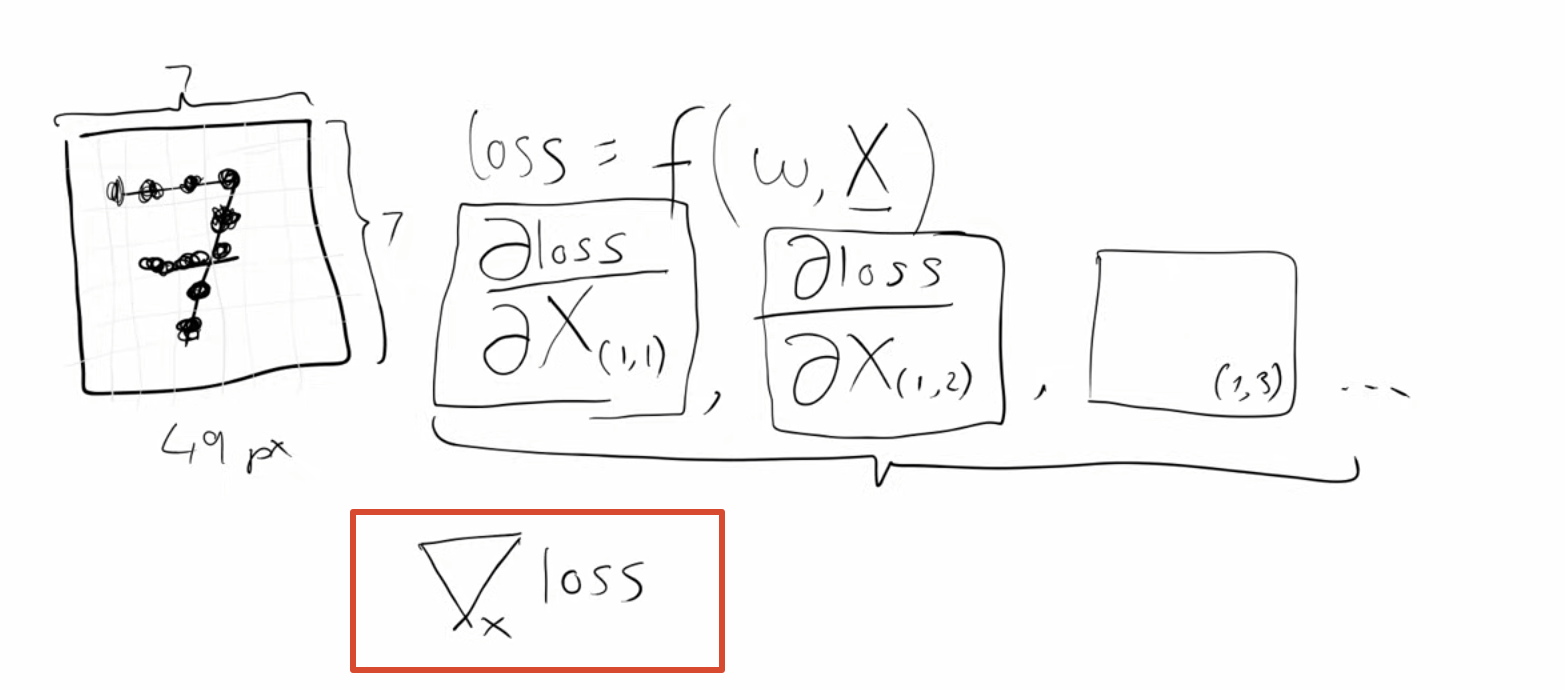
为什么这样就表示梯度了

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

这张图完美展示了 Jeremy 纠正记号的含义。

**这张图在说什么：**

1. **左边**：一个 7×7 = **49 像素的图片**（比如手写数字）。每个格子是一个像素值。

2. **中间**：`loss = f(w, X)` —— 这是损失函数（或概率函数）。
   * `∂loss/∂X_(1,1)` 表示：**改变第 1 行第 1 列的像素，loss 会怎么变？**
   * `∂loss/∂X_(1,2)` 表示：**改变第 1 行第 2 列的像素，loss 会怎么变？**
   * 以此类推……直到第 (7,7) 个像素。

3. **下方红框**：`∇_x loss`
   * **∇（nabla）** 就是把上面那**一长串偏导数**打包成一个整体。
   * 因为这里有 49 个像素，所以 ∇_x loss 就是一个包含 49 个数字的**向量**（或看作 7×7 的矩阵）。

**为什么是梯度？**
因为**梯度（gradient）的定义就是：对所有输入变量分别求偏导，然后把结果放在一起**。

* 单变量函数（1 个输入）：用 `df/dx`，结果是一个数。
* 多变量函数（49 个或 784 个像素）：用 `∇f`，结果是一个向量，每个分量对应一个像素的敏感度。

所以这张图展示了：**对于图片这种多维输入，我们不能只用简单的导数，而需要用 ∇ 来表示"每个像素该怎么调"的完整信息**。

这个概念清楚了吗？还是你想看看这 49 个数字具体怎么用来更新图片？

<details class='token-usage-details'><summary>$0.0310</summary>

`total=28,788 | in=27,375 | out=1,413 | cached=0.1% | reasoning=1,506 | searches=0 | $0.0310`

</details>


什么是有限差分

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

Jeremy 在视频里提到这个词时，是拿它和 **PyTorch 的自动求导**做对比。

## 有限差分法是什么

假设你有一个函数 $f$，想知道它在某个点的导数。**有限差分法的思路是：**

1. 给输入加一个**微小变化** $\Delta x$
2. 看看输出变化了多少 $\Delta f$
3. 用 $\frac{\Delta f}{\Delta x}$ 近似导数

## 回到 Jeremy 的例子

图片有 784 个像素。用有限差分法算梯度就是：

```
for 每个像素:
    把这个像素的值增加一点点（比如 +0.001）
    把整张图片传给 f，看概率变了多少
    (新概率 - 原概率) / 0.001 ≈ 这个像素的偏导数
```

这样你需要调用 **f 整整 784 次**，因为每次只改一个像素。

## 对比自动求导

而 PyTorch 的 `.backward()` 只需要**一次前向传播 + 一次反向传播**，就同时算出了所有 784 个偏导数。

## 一个简单的类比

| 方法 | 好比 |
|------|------|
| 有限差分法 | 你要调 784 个旋钮，每次只拧一个，看看效果——拧 784 次 |
| 自动求导 (backward) | 一次就告诉你所有旋钮该往哪拧 |

所以 Jeremy 说有限差分法"很慢"——它在概念上好理解，但实际训练中没有人用它。

<details class='token-usage-details'><summary>$0.0004</summary>

`total=28,843 | in=28,457 | out=386 | cached=95.4% | reasoning=51 | searches=0 | $0.0004`

</details>


自动求导本质上不是进行有限差分吗

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

好问题！它们**看起来很像**，但本质完全不同。让我用一个简单的例子来说明。

## 一个函数：$f(x) = x^2$

### 有限差分的做法
```
f(3) = 9
f(3.001) = 9.006001

导数 ≈ (9.006001 - 9) / 0.001 = 6.001
```
这是**近似值**，而且结果依赖你选的 $\Delta x$ 大小。

### 自动求导的做法
它知道 $f(x) = x^2$ 的**解析导数**是 $f'(x) = 2x$，所以：
```
f'(3) = 2 × 3 = 6
```
这是**精确值**。

---

## 关键区别

| | 有限差分 | 自动求导 |
|---|---|---|
| **黑盒还是白盒** | 把 $f$ 当黑盒，只看输入输出 | 知道 $f$ 内部每一步在做什么 |
| **精确吗** | 近似（有截断误差） | 精确（浮点精度内） |
| **算 784 个偏导需要** | 784 次前向传播 | 1 次前向 + 1 次反向 |

自动求导之所以精确，是因为它**记录了计算图**（每一步做了什么运算），然后用**链式法则**一步步反向传播。它不是"试一下输入变一点点输出变多少"，而是**解析地算出导数应该是多少**。

---

这个区别清楚了吗？还是想用一个更具体的例子（比如 $f(x) = \sin(x^2) + e^x$ 这种复杂函数）来看看自动求导具体是怎么一步步算的？

<details class='token-usage-details'><summary>$0.0005</summary>

`total=29,515 | in=28,856 | out=659 | cached=95.8% | reasoning=291 | searches=0 | $0.0005`

</details>
